<a href="https://colab.research.google.com/github/Prathamesh-kadam/SN2025qe-/blob/main/2025qe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Combining data of GIT and HCT**

In [ ]:
import pandas as pd
import numpy as np

# Define exact column names as they appear in original files
git_cols = ['JD', 'g', 'eg', 'r', 'er', 'i', 'ei', 'z', 'ez']
hct_cols = ['JD', 'u', 'eu', 'g', 'eg', 'r', 'er', 'i', 'ei', 'z', 'ez']

# Read files with proper column names
git_df = pd.read_csv('/content/drive/MyDrive/2025qe/git_sub_mag4_vishwajeet.txt',
                     sep=r'\s+', header=None, names=git_cols)

hct_df = pd.read_csv('/content/drive/MyDrive/2025qe/hct_sub_mag2_vishwajeet.txt',
                     sep=r'\s+', header=None, names=hct_cols)

# Add source column
git_df['source'] = 'GIT'
hct_df['source'] = 'HCT'

# Extract only matching columns from HCT (g,eg,r,er,i,ei,z,ez) - ignore u,eu
hct_matched = hct_df[['JD', 'g', 'eg', 'r', 'er', 'i', 'ei', 'z', 'ez', 'source']].copy()

# Combine GIT first, then matched HCT
combined_df = pd.concat([git_df, hct_matched], ignore_index=True)

# Convert JD to numeric and sort chronologically
combined_df['JD'] = pd.to_numeric(combined_df['JD'], errors='coerce')
combined_df = combined_df.sort_values('JD').reset_index(drop=True)

# Convert photometry columns: INDEF → NaN, keep numeric magnitudes/errors
phot_cols = ['g', 'eg', 'r', 'er', 'i', 'ei', 'z', 'ez']
for col in phot_cols:
    combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')

# Save combined light curve to CSV
combined_df.to_csv('SN2025qe_combined.csv', index=False)

# Display results
print("First 15 rows:")
print(combined_df.head(15))
print(f"\nCombined shape: {combined_df.shape}")
print("\nColumns:", combined_df.columns.tolist())
print("\nSample g,r,i bands by source:")
print(combined_df.groupby('source')[['g', 'r', 'i']].head(2))
print("\nFinal columns: JD, g, eg, r, er, i, ei, z, ez, source")


First 15 rows:
           JD      g     eg      r     er      i     ei      z     ez source
0   2460697.2  16.93  0.067  17.06  0.099  17.29  0.052  17.67  0.085    GIT
1   2460699.1  16.61  0.058  16.71  0.130  16.98  0.060    NaN    NaN    GIT
2   2460700.1  16.53  0.050  16.62  0.112  16.85  0.047    NaN    NaN    GIT
3   2460701.1  16.46  0.054  16.53  0.129  16.73  0.046  16.89  0.055    GIT
4   2460702.1  16.43  0.063  16.45  0.124  16.66  0.080  16.88  0.098    GIT
5   2460703.1  16.40  0.015  16.41  0.080  16.68  0.058    NaN    NaN    GIT
6   2460704.3  16.33  0.058  16.36  0.031  16.75  0.045  16.59  0.061    HCT
7   2460706.1  16.41  0.027    NaN    NaN  16.46  0.039    NaN    NaN    GIT
8   2460707.2  16.40  0.113  16.26  0.110  16.49  0.059  16.62  0.067    GIT
9   2460708.1  16.39  0.055    NaN    NaN    NaN    NaN    NaN    NaN    GIT
10  2460709.1    NaN    NaN    NaN    NaN  16.39  0.084    NaN    NaN    GIT
11  2460710.1    NaN    NaN  16.31  0.069  16.39  0.100    Na

**Plotting of GIT Data**

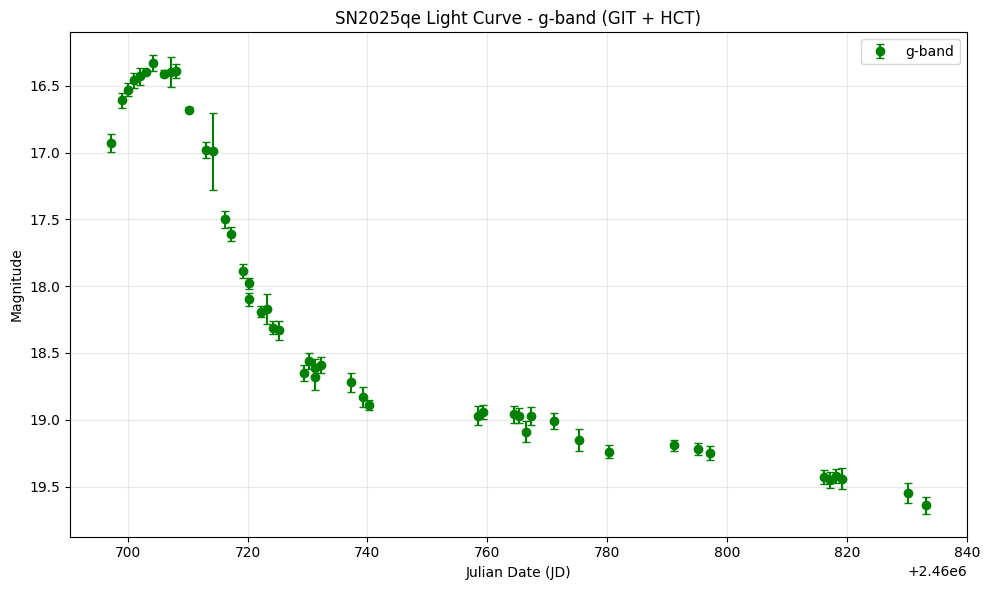

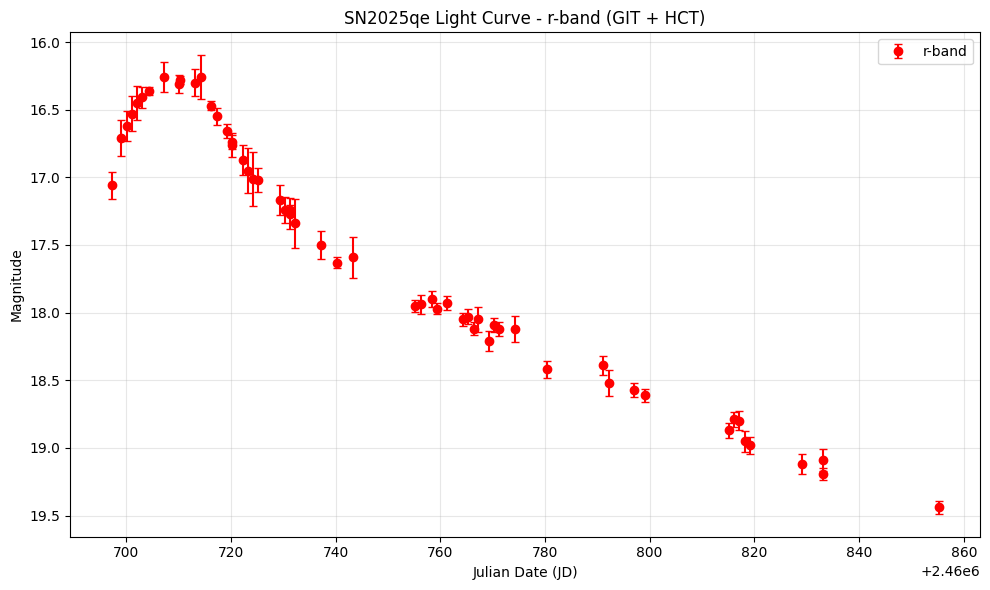

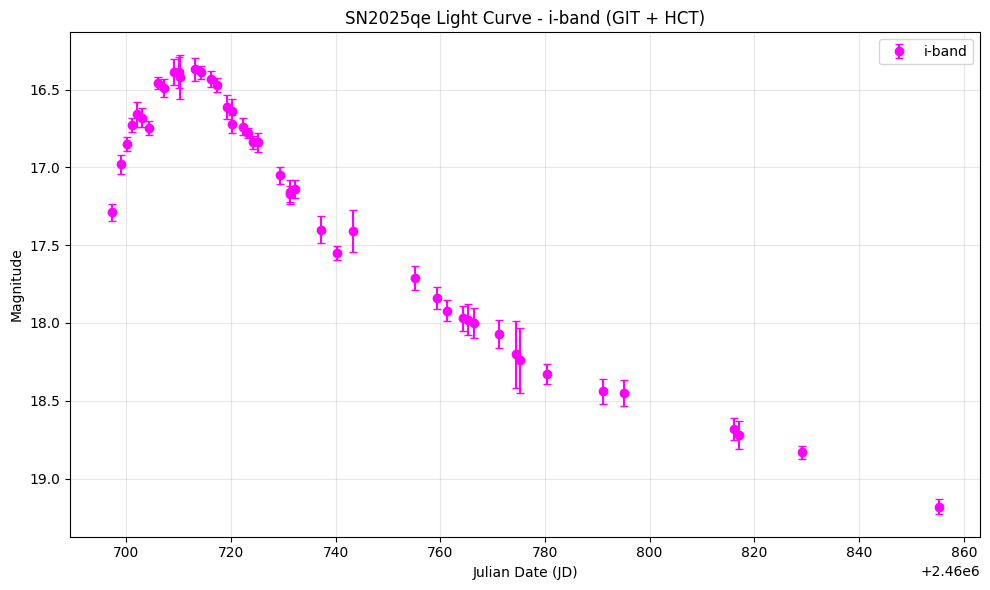

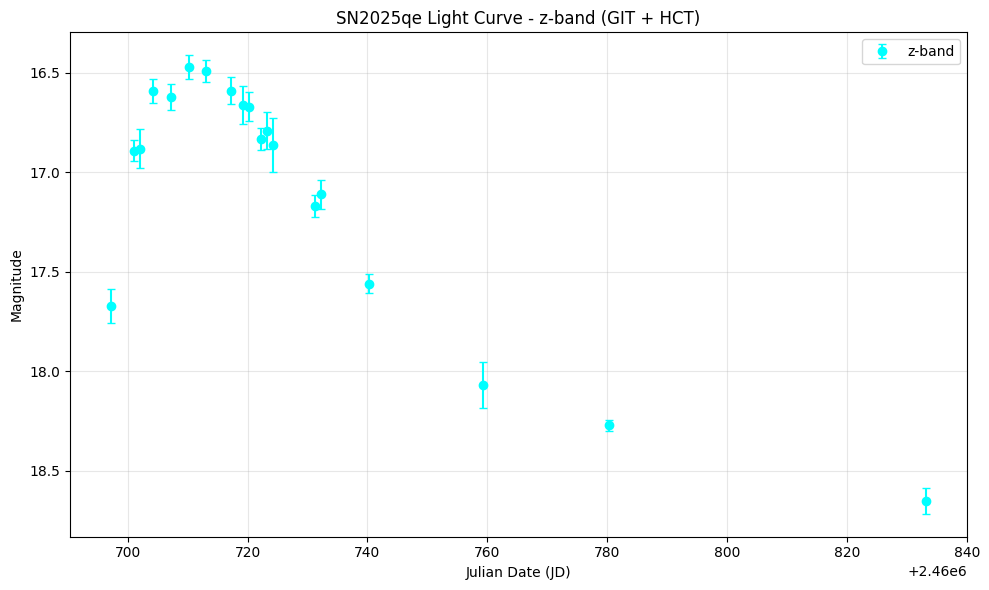

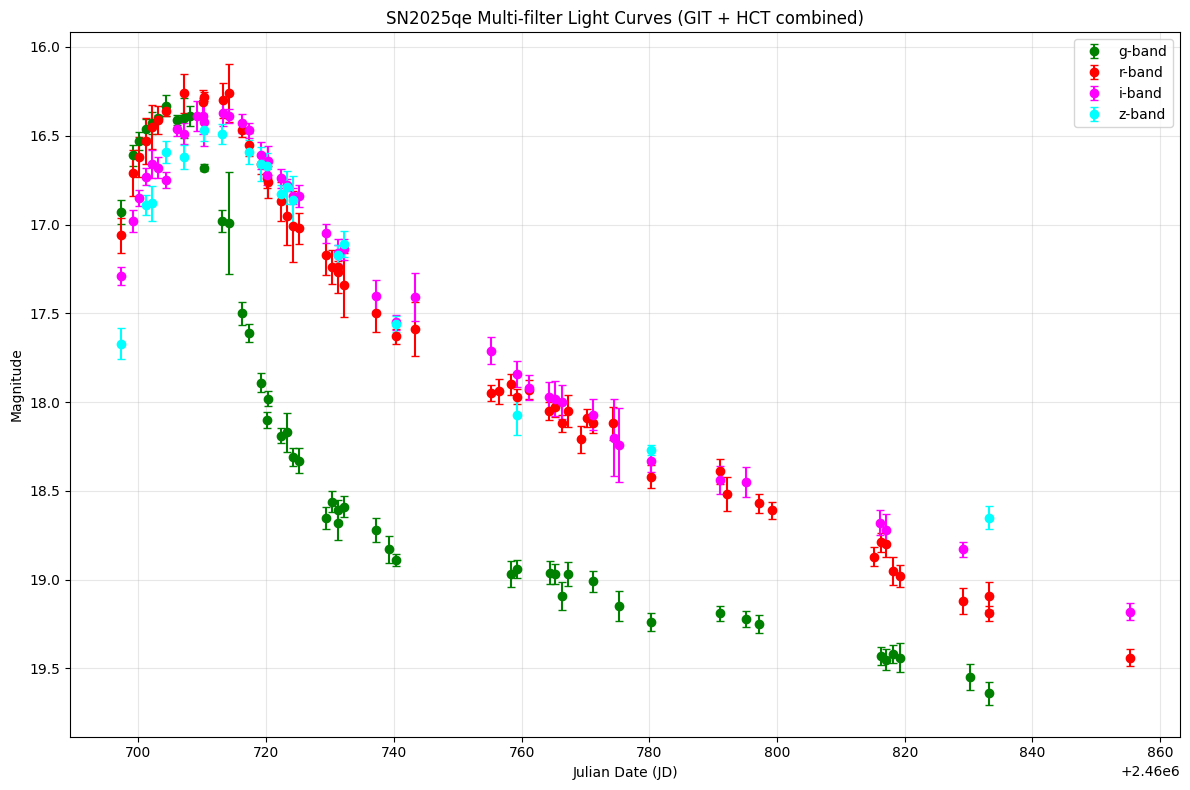

Data Summary:
g-band: 48 detections, mag range 16.33 - 19.64
r-band: 56 detections, mag range 16.26 - 19.44
i-band: 46 detections, mag range 16.37 - 19.18
z-band: 19 detections, mag range 16.47 - 18.65


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your combined CSV file
file_path = '/content/drive/MyDrive/2025qe/SN2025qe_combined (1).csv'
df = pd.read_csv(file_path)

# Define filters and their colors (griz standard colors)
filters = ['g', 'r', 'i', 'z']
colors = {'g': 'green', 'r': 'red', 'i': 'magenta', 'z': 'cyan'}

# Extract JD column
jd = df['JD']

# Function to get non-NaN data for plotting
def get_valid_data(df, filter_name):
    mag_col = filter_name
    err_col = f'e{mag_col}'  # eg, er, ei, ez
    mask = ~(df[mag_col].isna() | df[err_col].isna())
    return jd[mask], df[mag_col][mask], df[err_col][mask]

# Plot individual filter light curves
for f in filters:
    plt.figure(figsize=(10, 6))
    valid_jd, mags, errs = get_valid_data(df, f)

    plt.errorbar(valid_jd, mags, yerr=errs, fmt='o', color=colors[f],
                markersize=6, capsize=3, label=f'{f}-band')
    plt.gca().invert_yaxis()  # Magnitude scale reversed
    plt.xlabel('Julian Date (JD)')
    plt.ylabel('Magnitude')
    plt.title(f'SN2025qe Light Curve - {f}-band (GIT + HCT)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot ALL filters on single plot
plt.figure(figsize=(12, 8))
for f in filters:
    valid_jd, mags, errs = get_valid_data(df, f)
    plt.errorbar(valid_jd, mags, yerr=errs, fmt='o', color=colors[f],
                markersize=6, capsize=3, label=f'{f}-band')

plt.gca().invert_yaxis()
plt.xlabel('Julian Date (JD)')
plt.ylabel('Magnitude')
plt.title('SN2025qe Multi-filter Light Curves (GIT + HCT combined)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("Data Summary:")
for f in filters:
    valid_jd, mags, errs = get_valid_data(df, f)
    print(f"{f}-band: {len(valid_jd)} detections, mag range {mags.min():.2f} - {mags.max():.2f}")


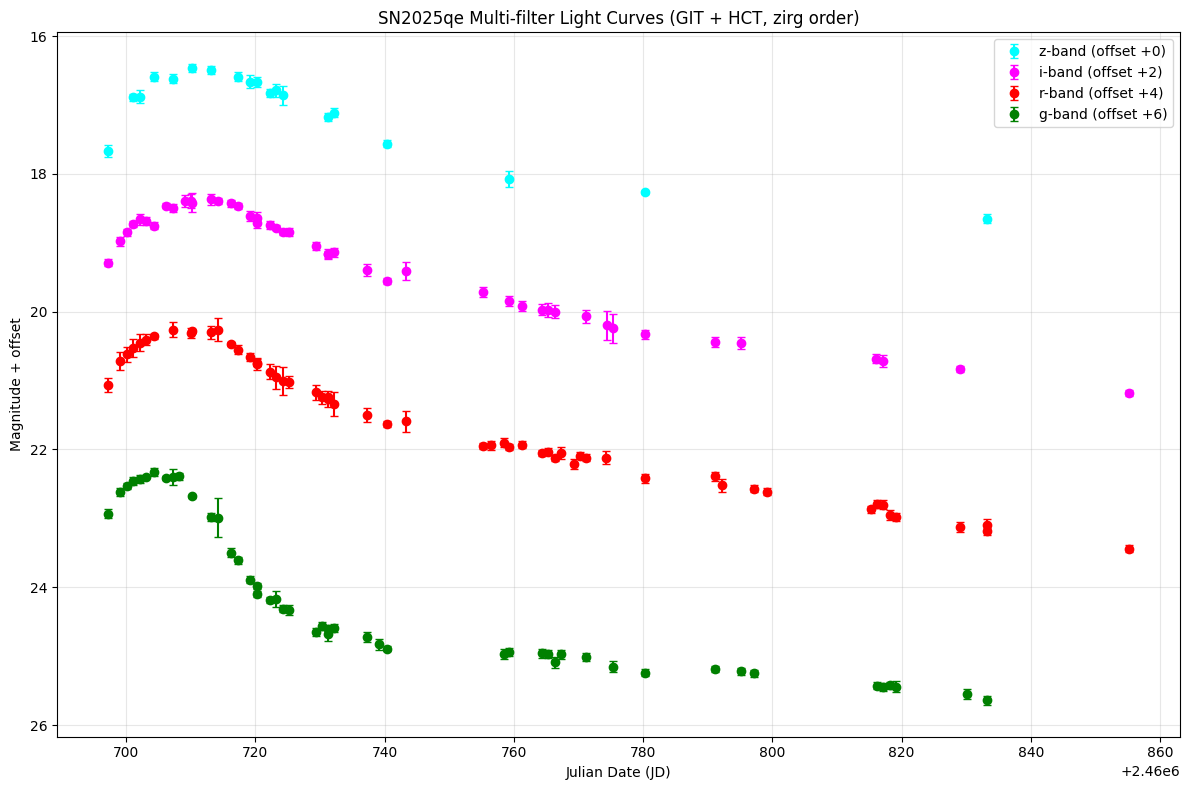

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your combined CSV file
file_path = '/content/drive/MyDrive/2025qe/SN2025qe_combined (1).csv'
df = pd.read_csv(file_path)

# Define filters in "zirg" order (z at bottom → g at top) and offsets
filters = ['z', 'i', 'r', 'g']  # Bottom to top order
colors = {'g': 'green', 'r': 'red', 'i': 'magenta', 'z': 'cyan'}
offsets = np.arange(len(filters)) * 2  # Offset by 2 mags each

# Extract JD column
jd = df['JD']

# Function to get non-NaN data for plotting
def get_valid_data(df, filter_name):
    mag_col = filter_name
    err_col = f'e{mag_col}'  # eg, er, ei, ez
    mask = ~(df[mag_col].isna() | df[err_col].isna())
    return jd[mask], df[mag_col][mask], df[err_col][mask]

# Plot multi-filter light curves WITH OFFSETS (zirg order: z bottom → g top)
plt.figure(figsize=(12, 8))
for idx, f in enumerate(filters):  # z=0, i=1, r=2, g=3 → z bottom, g top
    valid_jd, mags, errs = get_valid_data(df, f)
    mask = ~np.isnan(mags)
    y_offset = mags[mask] + offsets[idx]  # z:+0, i:+2, r:+4, g:+6
    yerr_offset = errs[mask]              # Error stays same

    plt.errorbar(valid_jd[mask], y_offset, yerr=yerr_offset,
                fmt='o', color=colors[f], markersize=6, capsize=3,
                label=f'{f}-band (offset +{offsets[idx]})')

plt.gca().invert_yaxis()
plt.xlabel('Julian Date (JD)')
plt.ylabel('Magnitude + offset')
plt.title('SN2025qe Multi-filter Light Curves (GIT + HCT, zirg order)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [3]:
pip install extinction


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.8/627.8 kB 10.6 MB/s eta 0:00:00


**Photometeric parameters of combined Data**

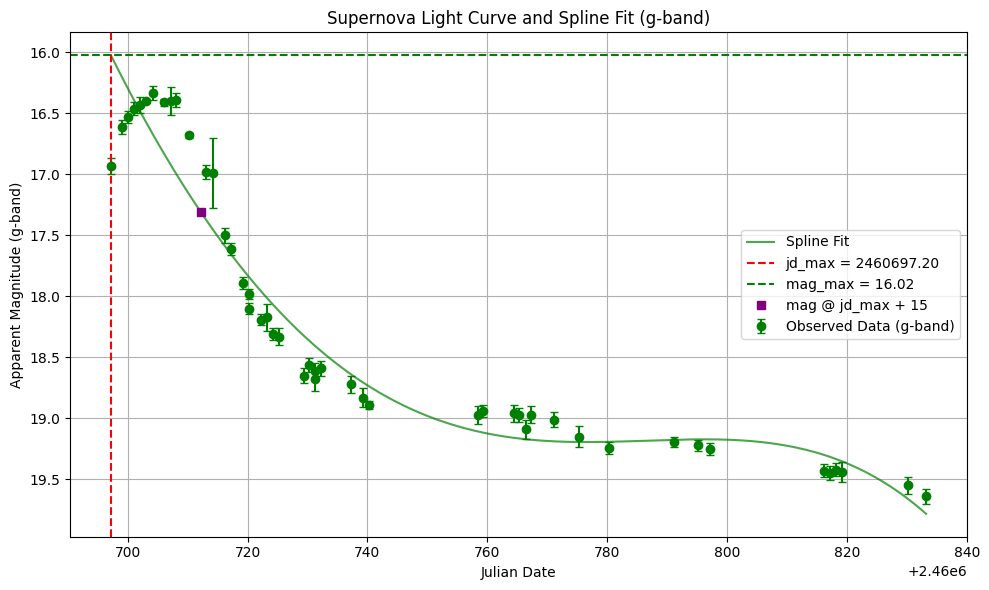

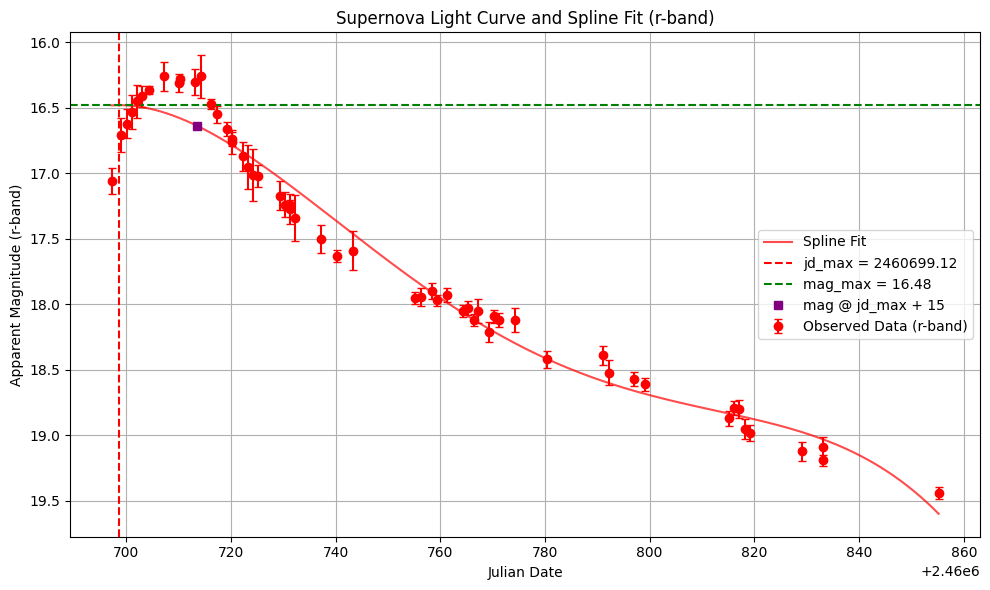

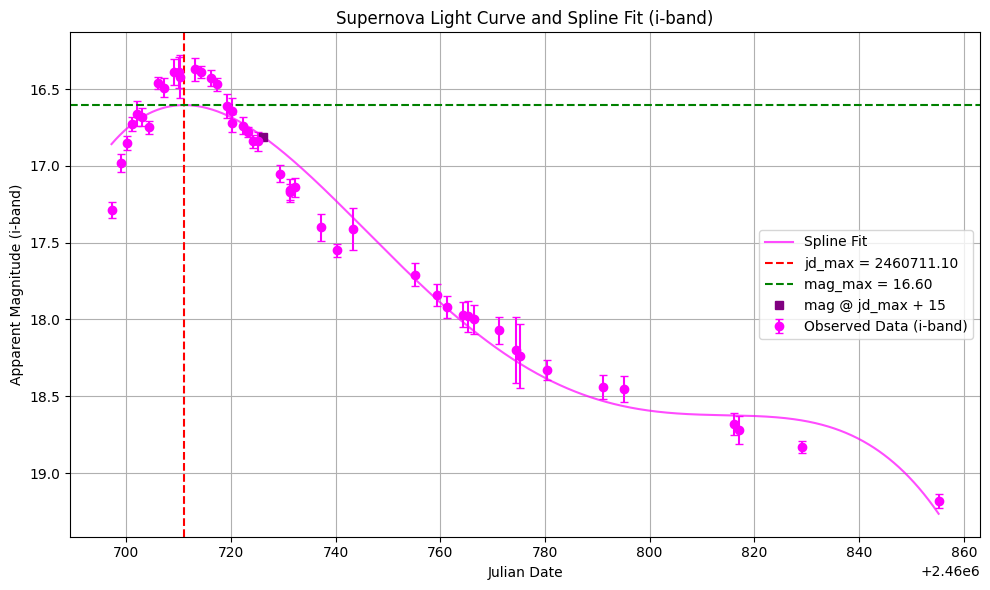

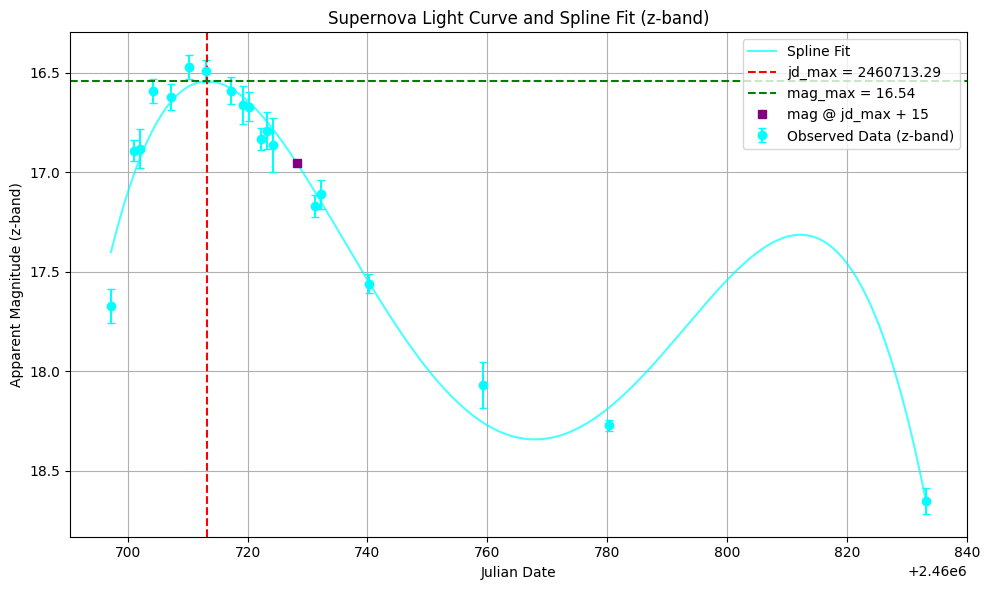


--- Summary of Light Curve Parameters ---

G-band:
  JD of Maximum Brightness (jd_max): 2460697.200 ± 0.000
  Maximum Apparent Magnitude (mag_max): 16.025 ± 0.028
  Maximum Absolute Magnitude (M_max): -16.499 ± 0.153
  Δm15: 1.284 ± 0.033

R-band:
  JD of Maximum Brightness (jd_max): 2460699.124 ± 1.817
  Maximum Apparent Magnitude (mag_max): 16.477 ± 0.043
  Maximum Absolute Magnitude (M_max): -16.027 ± 0.156
  Δm15: 0.165 ± 0.008

I-band:
  JD of Maximum Brightness (jd_max): 2460711.099 ± 0.545
  Maximum Apparent Magnitude (mag_max): 16.604 ± 0.015
  Maximum Absolute Magnitude (M_max): -15.884 ± 0.151
  Δm15: 0.204 ± 0.009

Z-band:
  JD of Maximum Brightness (jd_max): 2460713.292 ± 0.348
  Maximum Apparent Magnitude (mag_max): 16.542 ± 0.027
  Maximum Absolute Magnitude (M_max): -15.936 ± 0.152
  Δm15: 0.413 ± 0.023


,jd_max,jd_max_err,mag_max,mag_max_err,abs_mag,abs_mag_err,delta_m15,delta_m15_err
g,2.460697e+06,4.656613e-09,16.024645,0.028015,-16.499091,0.152594,1.284075,0.032969
r,2.460699e+06,1.816964e+00,16.476649,0.043258,-16.026532,0.156113,0.165468,0.007566
i,2.460711e+06,5.451760e-01,16.603866,0.014970,-15.884385,0.150745,0.204430,0.008839
z,2.460713e+06,3.479516e-01,16.542021,0.027184,-15.935816,0.152443,0.412930,0.023342


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from astropy.stats import sigma_clipped_stats
import extinction

file_path = '/content/drive/MyDrive/2025qe/SN2025qe_combined (1).csv'
df = pd.read_csv(file_path)

# Define filters, their central wavelengths (in Angstroms), and colors
filters_info = {
    'g': {'wave': 4816, 'color': 'green', 'label': 'g-band'},
    'r': {'wave': 6139, 'color': 'red', 'label': 'r-band'},
    'i': {'wave': 7480, 'color': 'magenta', 'label': 'i-band'},
    'z': {'wave': 8910, 'color': 'cyan', 'label': 'z-band'}
}

# Astrophysical parameters for absolute magnitude calculation
E_BV = 0.02
E_BV_err = 0.0003
modulus = 32.45
modulus_err = 0.15

results = {}

for f, info in filters_info.items():
    mag_col = f
    err_col = f'e{f}'

    # Filter out rows with NaN magnitudes or errors for the current band
    valid_data = df.dropna(subset=[mag_col, err_col]).copy()
    if valid_data.empty:
        print(f"No valid data for {f}-band. Skipping.")
        continue

    jd = valid_data['JD']
    mag = valid_data[mag_col]
    mag_err = valid_data[err_col]

    # Sort data by JD before spline fitting
    sort_idx = jd.argsort()
    jd = jd.iloc[sort_idx]
    mag = mag.iloc[sort_idx]
    mag_err = mag_err.iloc[sort_idx]

    # Ensure there are enough data points for spline fitting
    if len(jd) < 5: # UnivariateSpline needs at least k+1 points, k=4, so at least 5 points
        print(f"Not enough data points for {f}-band to perform spline fit. Skipping.")
        continue

    # --- Fit initial spline ---
    # s is a smoothing factor, adjust if spline is too wiggly or too smooth
    spline = UnivariateSpline(jd, mag, k=4, s=0.1 * len(jd))
    fine_jd = np.linspace(jd.min(), jd.max(), 1000)
    fine_mag = spline(fine_jd)

    # Find jd_max and mag_max from the spline
    jd_max = fine_jd[np.argmin(fine_mag)]
    mag_max = np.min(fine_mag)

    # Calculate initial delta_m15
    try:
        delta_m15 = spline(jd_max + 15) - mag_max
    except ValueError: # Handle cases where jd_max + 15 is outside the spline range
        delta_m15 = np.nan

    # --- Monte Carlo Simulation ---
    n_iter = 1000
    jd_max_sim = []
    mag_max_sim = []
    delta_m15_sim = []

    for i in range(n_iter):
        mag_sim = mag + np.random.normal(0, mag_err)
        spline_sim = UnivariateSpline(jd, mag_sim, k=4, s=0.1 * len(jd))
        fine_mag_sim = spline_sim(fine_jd)

        jd_peak_sim = fine_jd[np.argmin(fine_mag_sim)]
        mag_peak_sim = np.min(fine_mag_sim)

        jd_max_sim.append(jd_peak_sim)
        mag_max_sim.append(mag_peak_sim)

        try:
            mag_plus_15_sim = spline_sim(jd_peak_sim + 15)
            delta_m15_sim.append(mag_plus_15_sim - mag_peak_sim)
        except ValueError:
            delta_m15_sim.append(np.nan)

    # Convert to numpy arrays and clean NaNs for sigma_clipped_stats
    jd_max_sim = np.array(jd_max_sim)
    mag_max_sim = np.array(mag_max_sim)
    delta_m15_sim = np.array(delta_m15_sim)

    jd_max_sim = jd_max_sim[~np.isnan(jd_max_sim)]
    mag_max_sim = mag_max_sim[~np.isnan(mag_max_sim)]
    delta_m15_sim = delta_m15_sim[~np.isnan(delta_m15_sim)]

    # --- Sigma-Clipped Stats ---
    # Ensure enough data points for sigma_clipped_stats
    if len(jd_max_sim) > 0: # Check if array is not empty after NaN removal
        jd_max_mean, _, jd_max_std = sigma_clipped_stats(jd_max_sim)
    else:
        jd_max_mean, jd_max_std = np.nan, np.nan

    if len(mag_max_sim) > 0:
        mag_max_mean, _, mag_max_std = sigma_clipped_stats(mag_max_sim)
    else:
        mag_max_mean, mag_max_std = np.nan, np.nan

    if len(delta_m15_sim) > 0:
        delta_m15_mean, _, delta_m15_std = sigma_clipped_stats(delta_m15_sim)
    else:
        delta_m15_mean, delta_m15_std = np.nan, np.nan

    # --- Plot ---
    plt.figure(figsize=(10,6))
    plt.errorbar(jd, mag, yerr=mag_err, fmt='o', color=info['color'], label=f'Observed Data ({info["label"]})', capsize=3)
    plt.plot(fine_jd, fine_mag, '-', color=info['color'], alpha=0.7, label='Spline Fit')
    plt.axvline(jd_max, color='r', linestyle='--', label=f'jd_max = {jd_max_mean:.2f}')
    plt.axhline(mag_max, color='g', linestyle='--', label=f'mag_max = {mag_max_mean:.2f}')

    # Mark jd_max + 15
    try:
        mag_15 = spline(jd_max + 15)
        plt.plot(jd_max + 15, mag_15, 's', color='purple', label='mag @ jd_max + 15')
    except ValueError:
        pass # Do nothing if outside range

    plt.gca().invert_yaxis()
    plt.xlabel('Julian Date')
    plt.ylabel(f'Apparent Magnitude ({info["label"]})')
    plt.title(f'Supernova Light Curve and Spline Fit ({info["label"]})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Calculate Absolute Magnitude
    Av = 3.1 * E_BV
    wave_angstrom = np.array([info['wave']])
    ext = extinction.fm07(wave_angstrom, Av)[0]

    abs_mag_max = mag_max_mean - modulus - ext
    abs_mag_max_err = np.sqrt((mag_max_std)**2 + (modulus_err)**2)

    # Store results
    results[f] = {
        'jd_max': jd_max_mean,
        'jd_max_err': jd_max_std,
        'mag_max': mag_max_mean,
        'mag_max_err': mag_max_std,
        'abs_mag': abs_mag_max,
        'abs_mag_err': abs_mag_max_err,
        'delta_m15': delta_m15_mean,
        'delta_m15_err': delta_m15_std
    }

# Create a DataFrame from the results for better presentation
summary_df = pd.DataFrame.from_dict(results, orient='index')

# --- Output Results ---
print("\n--- Summary of Light Curve Parameters ---")
for f, row in summary_df.iterrows():
    print(f"\n{f.upper()}-band:")
    print(f"  JD of Maximum Brightness (jd_max): {row['jd_max']:.3f} \u00B1 {row['jd_max_err']:.3f}")
    print(f"  Maximum Apparent Magnitude (mag_max): {row['mag_max']:.3f} \u00B1 {row['mag_max_err']:.3f}")
    print(f"  Maximum Absolute Magnitude (M_max): {row['abs_mag']:.3f} \u00B1 {row['abs_mag_err']:.3f}")
    print(f"  \u0394m15: {row['delta_m15']:.3f} \u00B1 {row['delta_m15_err']:.3f}")

display(summary_df)


**UVOT Data**

Available columns: ['JD', 'U', 'U_Err', 'B', 'B_Err', 'V', 'V_Err', 'W1', 'W1_Err', 'M2', 'M2_Err', 'W2', 'W2_Err']

First 3 rows:
          JD        U   U_Err        B   B_Err        V   V_Err       W1  \
0  2460694.6  16.9919  0.1034  18.0909  0.1659    INDEF   INDEF  17.7922   
1  2460697.2  16.3307  0.0712  16.9586  0.0737   17.124  0.1609   17.414   
2  2460699.0  16.1952  0.0995   16.834   0.106  16.8916  0.2152  17.6214   

   W1_Err       M2 M2_Err     W2 W2_Err  
0   0.183    INDEF  INDEF  INDEF  INDEF  
1  0.1448  18.6721  0.178  INDEF  INDEF  
2  0.2059    INDEF  INDEF  INDEF  INDEF  


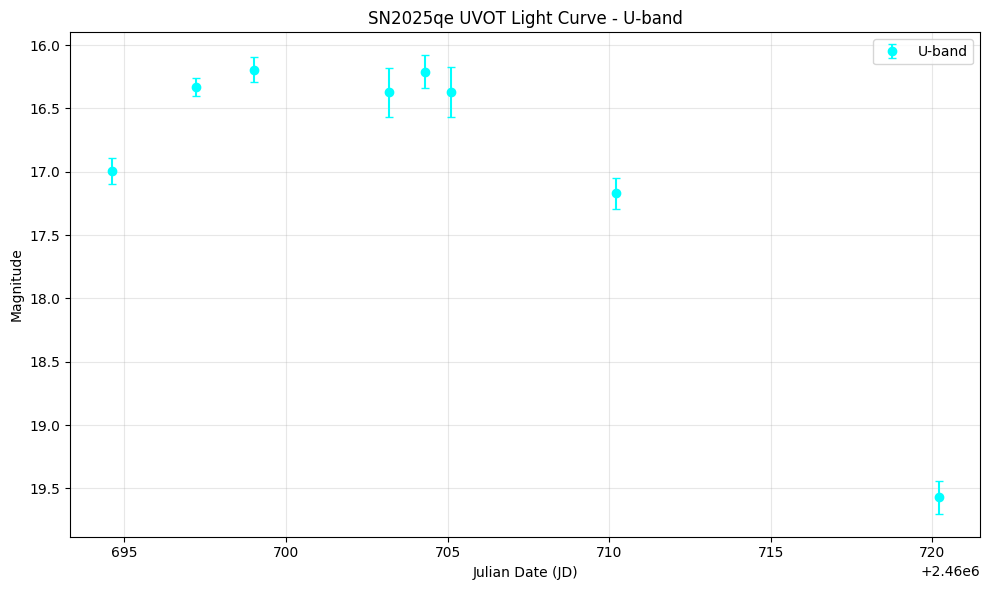

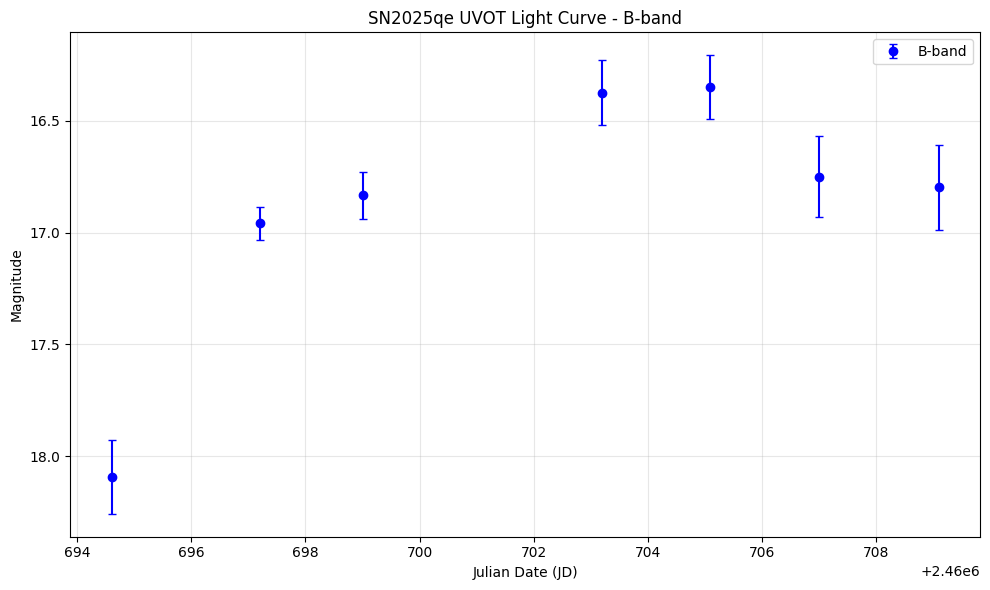

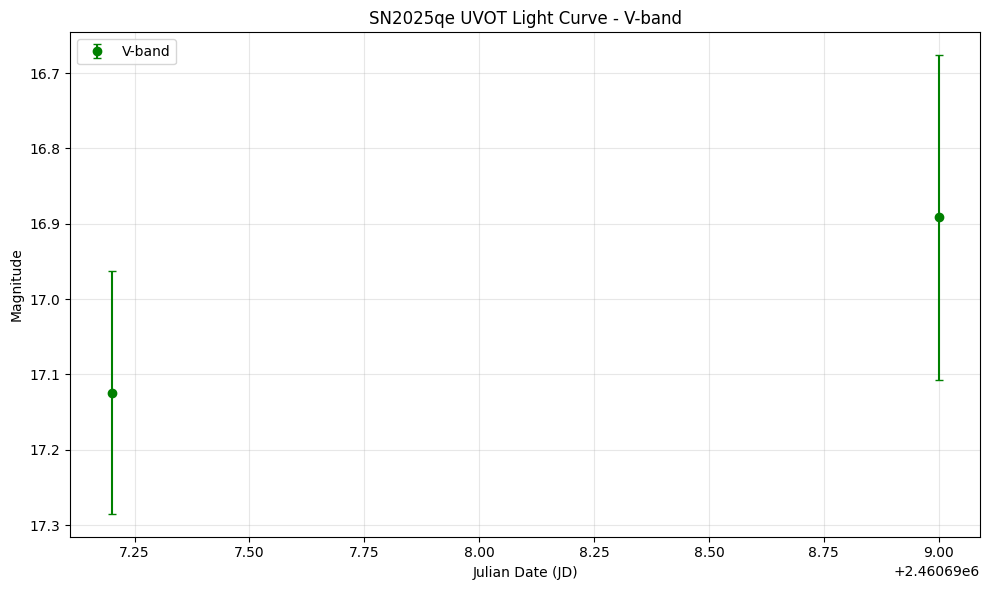

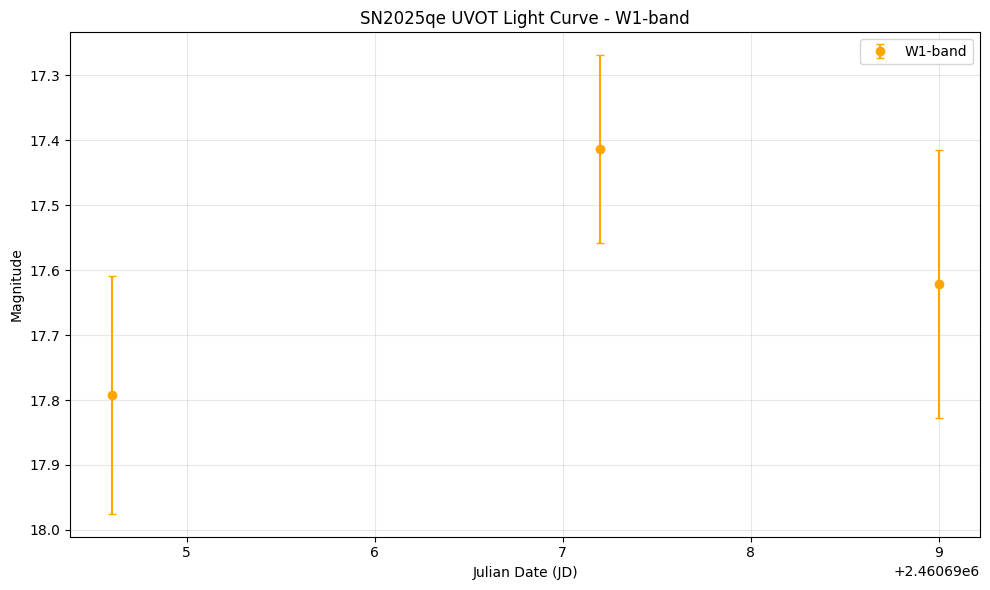

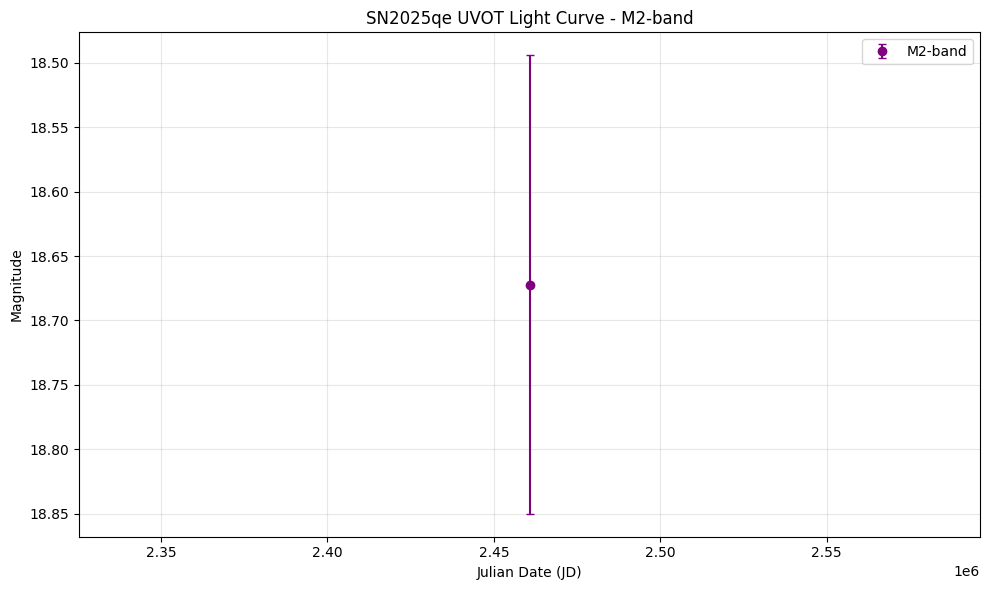

No valid data for W2-band


<Figure size 1000x600 with 0 Axes>

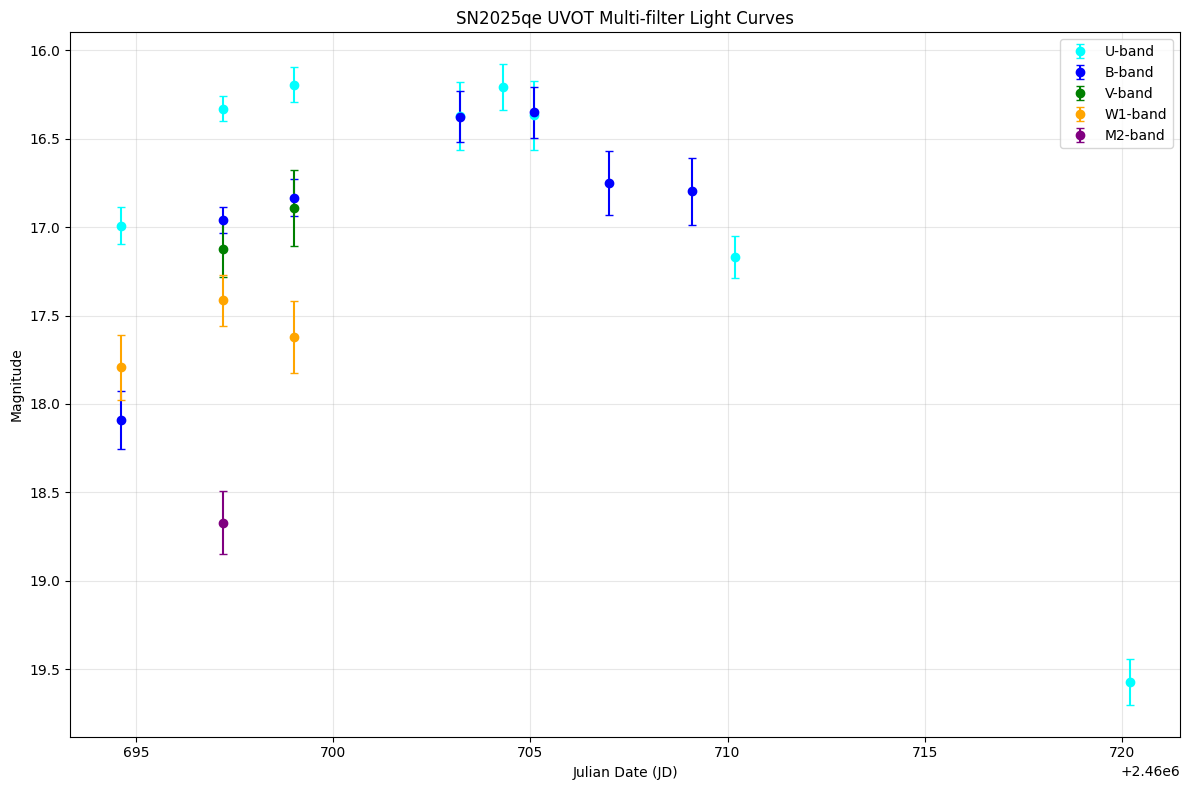


UVOT Data Summary:
U-band: 8 detections, mag range 16.20 - 19.57
B-band: 7 detections, mag range 16.35 - 18.09
V-band: 2 detections, mag range 16.89 - 17.12
W1-band: 3 detections, mag range 17.41 - 17.79
M2-band: 1 detections, mag range 18.67 - 18.67
W2-band: No valid data


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# FIXED: Use sep=r'\s+' (modern replacement for delim_whitespace)
file_path = '/content/drive/MyDrive/2025qe/UVOT_Photometry_Table.dat'
df = pd.read_csv(file_path, sep=r'\s+')  # Fixed whitespace parsing

# DEBUG: Check columns first
print("Available columns:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))

# Replace INDEF with NaN and convert to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Define UVOT filters and colors
filters = ['U', 'B', 'V', 'W1', 'M2', 'W2']
colors = {'U': 'cyan', 'B': 'blue', 'V': 'green', 'W1': 'orange',
          'M2': 'purple', 'W2': 'magenta'}

# Extract JD column
jd = df['JD']

# Function to get non-NaN data for plotting
def get_valid_data(df, filter_name):
    mag_col = filter_name
    err_col = f'{filter_name}_Err'
    mask = ~(df[mag_col].isna() | df[err_col].isna())
    return jd[mask], df[mag_col][mask], df[err_col][mask]

# Plot individual filter light curves
for f in filters:
    plt.figure(figsize=(10, 6))
    valid_jd, mags, errs = get_valid_data(df, f)

    if len(valid_jd) > 0:
        plt.errorbar(valid_jd, mags, yerr=errs, fmt='o', color=colors[f],
                    markersize=6, capsize=3, label=f'{f}-band')
        plt.gca().invert_yaxis()
        plt.xlabel('Julian Date (JD)')
        plt.ylabel('Magnitude')
        plt.title(f'SN2025qe UVOT Light Curve - {f}-band')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No valid data for {f}-band")

# Plot ALL filters on single plot
plt.figure(figsize=(12, 8))
for f in filters:
    valid_jd, mags, errs = get_valid_data(df, f)
    if len(valid_jd) > 0:
        plt.errorbar(valid_jd, mags, yerr=errs, fmt='o', color=colors[f],
                    markersize=6, capsize=3, label=f'{f}-band')

plt.gca().invert_yaxis()
plt.xlabel('Julian Date (JD)')
plt.ylabel('Magnitude')
plt.title('SN2025qe UVOT Multi-filter Light Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nUVOT Data Summary:")
for f in filters:
    valid_jd, mags, errs = get_valid_data(df, f)
    if len(valid_jd) > 0:
        print(f"{f}-band: {len(valid_jd)} detections, mag range {mags.min():.2f} - {mags.max():.2f}")
    else:
        print(f"{f}-band: No valid data")


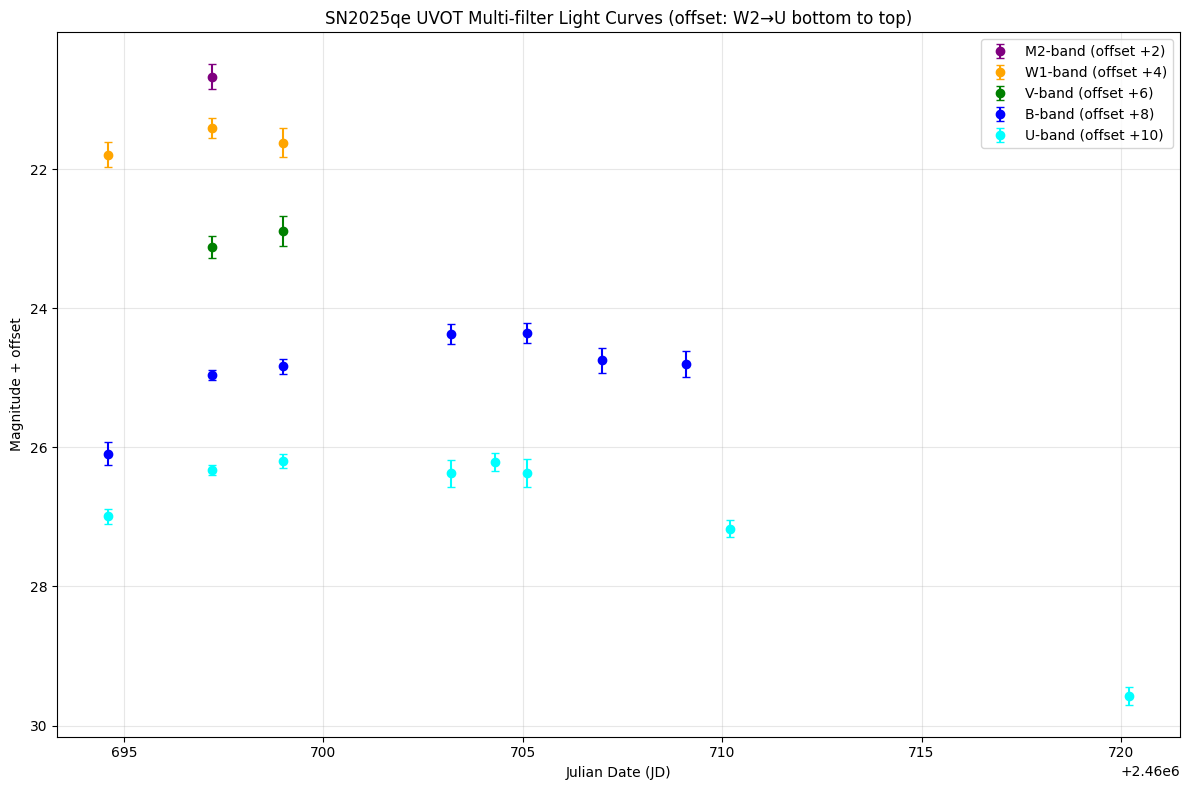

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load UVOT photometry data
file_path = '/content/drive/MyDrive/2025qe/UVOT_Photometry_Table.dat'
df = pd.read_csv(file_path, sep=r'\s+')

# Replace INDEF with NaN and convert to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Define UVOT filters in desired order and offsets
filters = ['W2', 'M2', 'W1', 'V', 'B', 'U']  # Bottom to top: UV to optical
colors = {'U': 'cyan', 'B': 'blue', 'V': 'green', 'W1': 'orange',
          'M2': 'purple', 'W2': 'magenta'}
offsets = np.arange(len(filters)) * 2  # Offset by 2 mags each

# Extract JD column
jd = df['JD']

# Function to get non-NaN data for plotting
def get_valid_data(df, filter_name):
    mag_col = filter_name
    err_col = f'{filter_name}_Err'
    mask = ~(df[mag_col].isna() | df[err_col].isna())
    return jd[mask], df[mag_col][mask], df[err_col][mask]

# Plot multi-filter light curves WITH OFFSETS (W2 bottom → U top)
plt.figure(figsize=(12, 8))
for idx, f in enumerate(filters):  # W2=0, M2=1, W1=2, V=3, B=4, U=5
    valid_jd, mags, errs = get_valid_data(df, f)
    mask = ~np.isnan(mags)
    if len(valid_jd[mask]) > 0:
        y_offset = mags[mask] + offsets[idx]  # W2:+0, U:+10 (top)
        yerr_offset = errs[mask]

        plt.errorbar(valid_jd[mask], y_offset, yerr=yerr_offset,
                    fmt='o', color=colors[f], markersize=6, capsize=3,
                    label=f'{f}-band (offset +{offsets[idx]})')

plt.gca().invert_yaxis()
plt.xlabel('Julian Date (JD)')
plt.ylabel('Magnitude + offset')
plt.title('SN2025qe UVOT Multi-filter Light Curves (offset: W2→U bottom to top)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


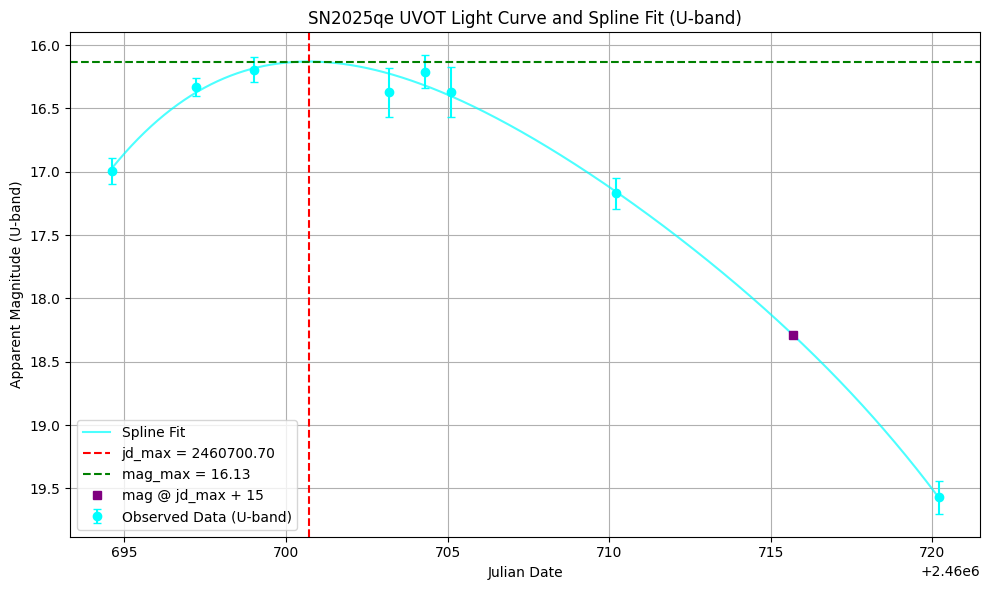

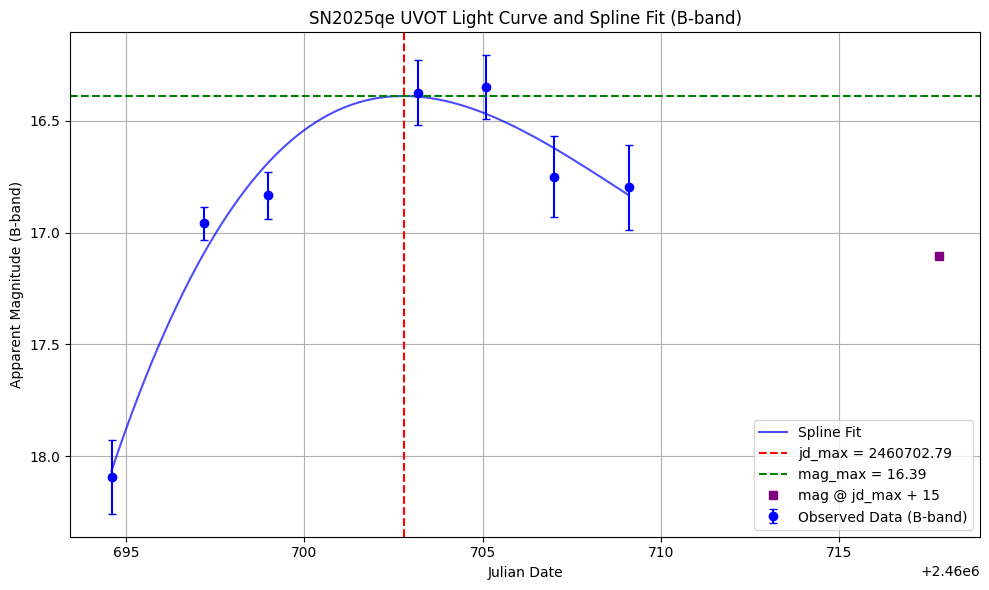

Not enough data points for V-band to perform spline fit. Skipping.
Not enough data points for W1-band to perform spline fit. Skipping.
Not enough data points for M2-band to perform spline fit. Skipping.
No valid data for W2-band. Skipping.

--- SN2025qe UVOT Light Curve Parameters ---

U-band:
  JD of Maximum Brightness (jd_max): 2460700.715 ± 0.684
  Maximum Apparent Magnitude (mag_max): 16.121 ± 0.072
  Maximum Absolute Magnitude (M_max): -16.428 ± 0.166
  Δm15: 2.183 ± 0.432

B-band:
  JD of Maximum Brightness (jd_max): 2460703.243 ± 1.361
  Maximum Apparent Magnitude (mag_max): 16.357 ± 0.108
  Maximum Absolute Magnitude (M_max): -16.174 ± 0.185
  Δm15: 2.546 ± 13.868

Summary Table:


,jd_max,jd_max_err,mag_max,mag_max_err,abs_mag,abs_mag_err,delta_m15,delta_m15_err
U,2.460701e+06,0.683912,16.121249,0.071755,-16.427592,0.166279,2.182963,0.431778
B,2.460703e+06,1.360740,16.357175,0.108284,-16.174109,0.185001,2.546190,13.868104


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from astropy.stats import sigma_clipped_stats
import extinction

# Load UVOT photometry data
file_path = '/content/drive/MyDrive/2025qe/UVOT_Photometry_Table.dat'
df = pd.read_csv(file_path, sep=r'\s+')

# Convert INDEF to NaN
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Define UVOT filters, their central wavelengths (in Angstroms), and colors
filters_info = {
    'U': {'wave': 3465, 'color': 'cyan', 'label': 'U-band'},
    'B': {'wave': 4392, 'color': 'blue', 'label': 'B-band'},
    'V': {'wave': 5468, 'color': 'green', 'label': 'V-band'},
    'W1': {'wave': 2600, 'color': 'orange', 'label': 'UVW1-band'},
    'M2': {'wave': 2246, 'color': 'purple', 'label': 'u-band'},
    'W2': {'wave': 1930, 'color': 'magenta', 'label': 'UVW2-band'}
}

# Astrophysical parameters for absolute magnitude calculation
E_BV = 0.02
E_BV_err = 0.0003
modulus = 32.45
modulus_err = 0.15

results = {}

for f, info in filters_info.items():
    mag_col = f
    err_col = f'{f}_Err'

    # Filter out rows with NaN magnitudes or errors for the current band
    valid_data = df.dropna(subset=[mag_col, err_col]).copy()
    if valid_data.empty:
        print(f"No valid data for {f}-band. Skipping.")
        continue

    jd = valid_data['JD']
    mag = valid_data[mag_col]
    mag_err = valid_data[err_col]

    # Sort data by JD before spline fitting
    sort_idx = jd.argsort()
    jd = jd.iloc[sort_idx]
    mag = mag.iloc[sort_idx]
    mag_err = mag_err.iloc[sort_idx]

    # Ensure there are enough data points for spline fitting
    if len(jd) < 5:
        print(f"Not enough data points for {f}-band to perform spline fit. Skipping.")
        continue

    # --- Fit initial spline ---
    spline = UnivariateSpline(jd, mag, k=4, s=0.1 * len(jd))
    fine_jd = np.linspace(jd.min(), jd.max(), 1000)
    fine_mag = spline(fine_jd)

    # Find jd_max and mag_max from the spline
    jd_max = fine_jd[np.argmin(fine_mag)]
    mag_max = np.min(fine_mag)

    # Calculate initial delta_m15
    try:
        delta_m15 = spline(jd_max + 15) - mag_max
    except ValueError:
        delta_m15 = np.nan

    # --- Monte Carlo Simulation ---
    n_iter = 100000
    jd_max_sim = []
    mag_max_sim = []
    delta_m15_sim = []

    for i in range(n_iter):
        mag_sim = mag + np.random.normal(0, mag_err)
        spline_sim = UnivariateSpline(jd, mag_sim, k=4, s=0.1 * len(jd))
        fine_mag_sim = spline_sim(fine_jd)

        jd_peak_sim = fine_jd[np.argmin(fine_mag_sim)]
        mag_peak_sim = np.min(fine_mag_sim)

        jd_max_sim.append(jd_peak_sim)
        mag_max_sim.append(mag_peak_sim)

        try:
            mag_plus_15_sim = spline_sim(jd_peak_sim + 15)
            delta_m15_sim.append(mag_plus_15_sim - mag_peak_sim)
        except ValueError:
            delta_m15_sim.append(np.nan)

    # Convert to numpy arrays and clean NaNs
    jd_max_sim = np.array(jd_max_sim)
    mag_max_sim = np.array(mag_max_sim)
    delta_m15_sim = np.array(delta_m15_sim)

    jd_max_sim = jd_max_sim[~np.isnan(jd_max_sim)]
    mag_max_sim = mag_max_sim[~np.isnan(mag_max_sim)]
    delta_m15_sim = delta_m15_sim[~np.isnan(delta_m15_sim)]

    # --- Sigma-Clipped Stats ---
    if len(jd_max_sim) > 0:
        jd_max_mean, _, jd_max_std = sigma_clipped_stats(jd_max_sim)
    else:
        jd_max_mean, jd_max_std = np.nan, np.nan

    if len(mag_max_sim) > 0:
        mag_max_mean, _, mag_max_std = sigma_clipped_stats(mag_max_sim)
    else:
        mag_max_mean, mag_max_std = np.nan, np.nan

    if len(delta_m15_sim) > 0:
        delta_m15_mean, _, delta_m15_std = sigma_clipped_stats(delta_m15_sim)
    else:
        delta_m15_mean, delta_m15_std = np.nan, np.nan

    # --- Plot ---
    plt.figure(figsize=(10,6))
    plt.errorbar(jd, mag, yerr=mag_err, fmt='o', color=info['color'],
                label=f'Observed Data ({info["label"]})', capsize=3)
    plt.plot(fine_jd, fine_mag, '-', color=info['color'], alpha=0.7, label='Spline Fit')
    plt.axvline(jd_max, color='r', linestyle='--', label=f'jd_max = {jd_max:.2f}')
    plt.axhline(mag_max, color='g', linestyle='--', label=f'mag_max = {mag_max:.2f}')

    # Mark jd_max + 15
    try:
        mag_15 = spline(jd_max + 15)
        plt.plot(jd_max + 15, mag_15, 's', color='purple', label='mag @ jd_max + 15')
    except ValueError:
        pass

    plt.gca().invert_yaxis()
    plt.xlabel('Julian Date')
    plt.ylabel(f'Apparent Magnitude ({info["label"]})')
    plt.title(f'SN2025qe UVOT Light Curve and Spline Fit ({info["label"]})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Calculate Absolute Magnitude
    Av = 3.1 * E_BV
    wave_angstrom = np.array([info['wave']])
    ext = extinction.fm07(wave_angstrom, Av)[0]

    abs_mag_max = mag_max_mean - modulus - ext
    abs_mag_max_err = np.sqrt((mag_max_std)**2 + (modulus_err)**2)

    # Store results
    results[f] = {
        'jd_max': jd_max_mean,
        'jd_max_err': jd_max_std,
        'mag_max': mag_max_mean,
        'mag_max_err': mag_max_std,
        'abs_mag': abs_mag_max,
        'abs_mag_err': abs_mag_max_err,
        'delta_m15': delta_m15_mean,
        'delta_m15_err': delta_m15_std
    }

# Create a DataFrame from the results
summary_df = pd.DataFrame.from_dict(results, orient='index')

# --- Output Results ---
print("\n--- SN2025qe UVOT Light Curve Parameters ---")
for f, row in summary_df.iterrows():
    print(f"\n{f.upper()}-band:")
    print(f"  JD of Maximum Brightness (jd_max): {row['jd_max']:.3f} ± {row['jd_max_err']:.3f}")
    print(f"  Maximum Apparent Magnitude (mag_max): {row['mag_max']:.3f} ± {row['mag_max_err']:.3f}")
    print(f"  Maximum Absolute Magnitude (M_max): {row['abs_mag']:.3f} ± {row['abs_mag_err']:.3f}")
    print(f"  Δm15: {row['delta_m15']:.3f} ± {row['delta_m15_err']:.3f}")

print("\nSummary Table:")
display(summary_df)


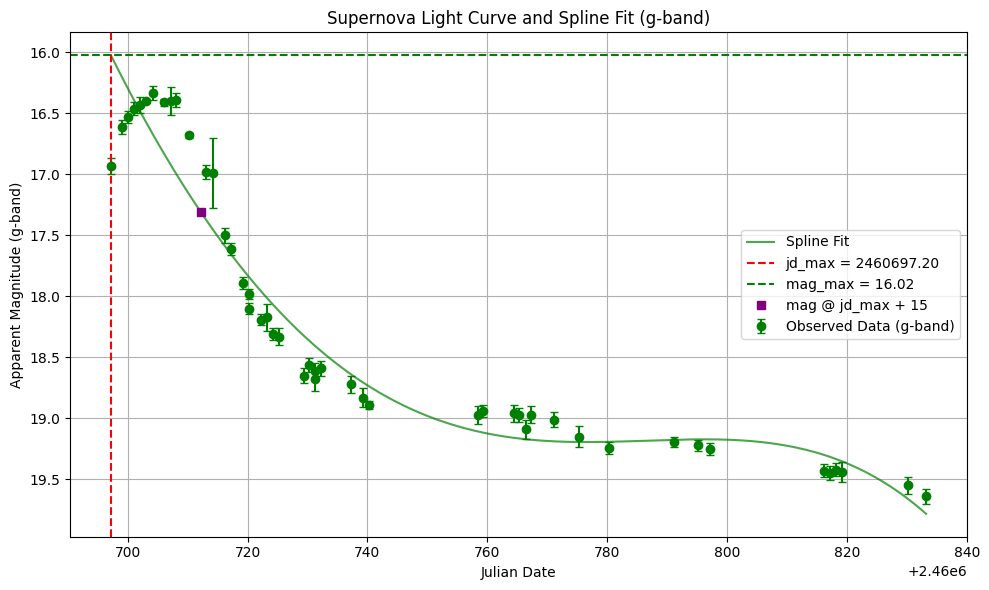

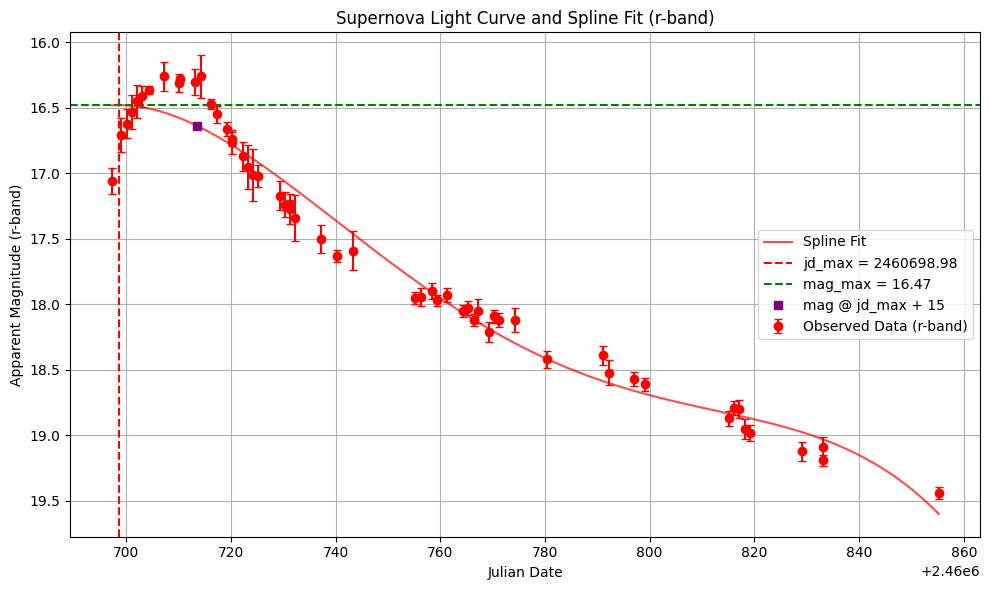

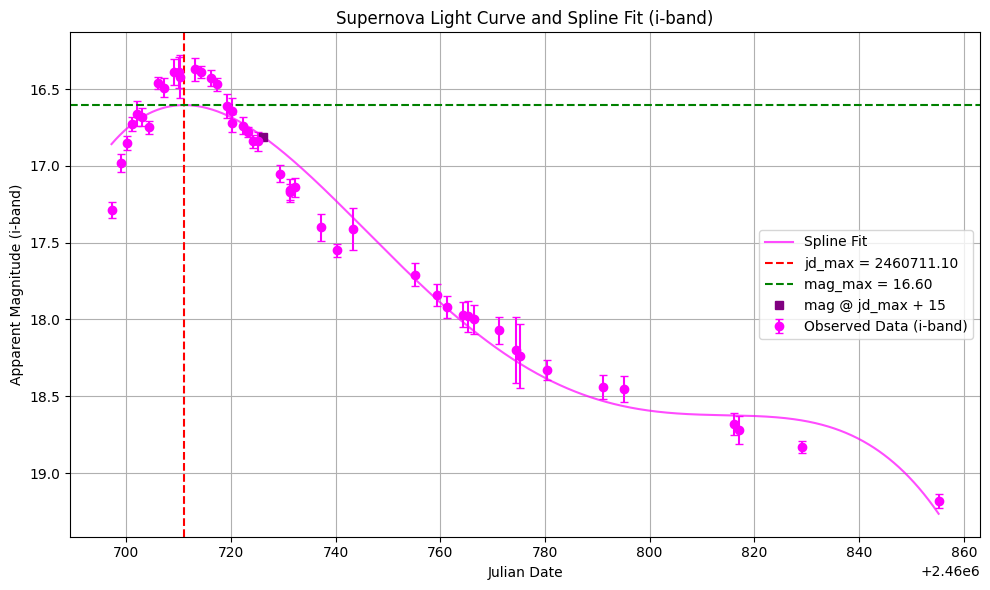

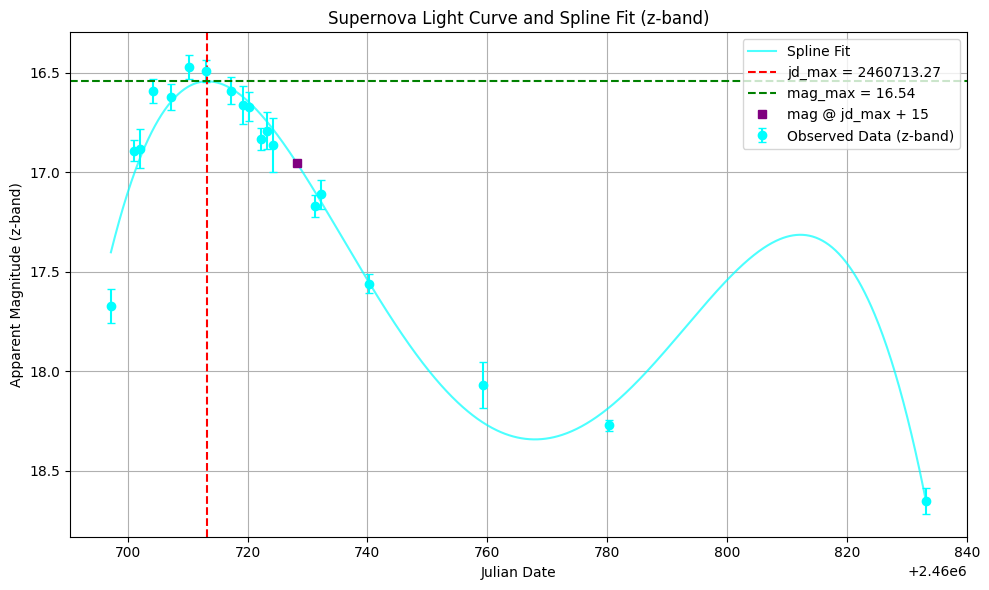


--- Summary of Light Curve Parameters ---

G-band:
  JD of Maximum Brightness (jd_max): 2460697.200 ± 0.000
  Maximum Apparent Magnitude (mag_max): 16.023 ± 0.029
  Maximum Absolute Magnitude (M_max): -16.501 ± 0.153
  Δm15: 1.285 ± 0.035

R-band:
  JD of Maximum Brightness (jd_max): 2460698.978 ± 1.721
  Maximum Apparent Magnitude (mag_max): 16.475 ± 0.042
  Maximum Absolute Magnitude (M_max): -16.028 ± 0.156
  Δm15: 0.166 ± 0.008

I-band:
  JD of Maximum Brightness (jd_max): 2460711.099 ± 0.536
  Maximum Apparent Magnitude (mag_max): 16.603 ± 0.014
  Maximum Absolute Magnitude (M_max): -15.885 ± 0.151
  Δm15: 0.205 ± 0.009

Z-band:
  JD of Maximum Brightness (jd_max): 2460713.267 ± 0.382
  Maximum Apparent Magnitude (mag_max): 16.543 ± 0.026
  Maximum Absolute Magnitude (M_max): -15.935 ± 0.152
  Δm15: 0.414 ± 0.024


,jd_max,jd_max_err,mag_max,mag_max_err,abs_mag,abs_mag_err,delta_m15,delta_m15_err
g,2.460697e+06,4.656613e-09,16.022827,0.028512,-16.500909,0.152686,1.285291,0.034764
r,2.460699e+06,1.721087e+00,16.474688,0.042381,-16.028494,0.155872,0.165512,0.008102
i,2.460711e+06,5.360487e-01,16.603355,0.014426,-15.884896,0.150692,0.204704,0.008636
z,2.460713e+06,3.815045e-01,16.543117,0.025944,-15.934720,0.152227,0.414122,0.023747


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from astropy.stats import sigma_clipped_stats
import extinction

file_path = '/content/drive/MyDrive/2025qe/SN2025qe_combined (1).csv'
df = pd.read_csv(file_path)

# Define filters, their central wavelengths (in Angstroms), and colors
filters_info = {
    'g': {'wave': 4816, 'color': 'green', 'label': 'g-band'},
    'r': {'wave': 6139, 'color': 'red', 'label': 'r-band'},
    'i': {'wave': 7480, 'color': 'magenta', 'label': 'i-band'},
    'z': {'wave': 8910, 'color': 'cyan', 'label': 'z-band'}
}

# Astrophysical parameters for absolute magnitude calculation
E_BV = 0.02
E_BV_err = 0.0003
modulus = 32.45
modulus_err = 0.15

results = {}

for f, info in filters_info.items():
    mag_col = f
    err_col = f'e{f}'

    # Filter out rows with NaN magnitudes or errors for the current band
    valid_data = df.dropna(subset=[mag_col, err_col]).copy()
    if valid_data.empty:
        print(f"No valid data for {f}-band. Skipping.")
        continue

    jd = valid_data['JD']
    mag = valid_data[mag_col]
    mag_err = valid_data[err_col]

    # Sort data by JD before spline fitting
    sort_idx = jd.argsort()
    jd = jd.iloc[sort_idx]
    mag = mag.iloc[sort_idx]
    mag_err = mag_err.iloc[sort_idx]

    # Ensure there are enough data points for spline fitting
    if len(jd) < 5: # UnivariateSpline needs at least k+1 points, k=4, so at least 5 points
        print(f"Not enough data points for {f}-band to perform spline fit. Skipping.")
        continue

    # --- Fit initial spline ---
    # s is a smoothing factor, adjust if spline is too wiggly or too smooth
    spline = UnivariateSpline(jd, mag, k=4, s=0.1 * len(jd))
    fine_jd = np.linspace(jd.min(), jd.max(), 1000)
    fine_mag = spline(fine_jd)

    # Find jd_max and mag_max from the spline
    jd_max = fine_jd[np.argmin(fine_mag)]
    mag_max = np.min(fine_mag)

    # Calculate initial delta_m15
    try:
        delta_m15 = spline(jd_max + 15) - mag_max
    except ValueError: # Handle cases where jd_max + 15 is outside the spline range
        delta_m15 = np.nan

    # --- Monte Carlo Simulation ---
    n_iter = 1000
    jd_max_sim = []
    mag_max_sim = []
    delta_m15_sim = []

    for i in range(n_iter):
        mag_sim = mag + np.random.normal(0, mag_err)
        spline_sim = UnivariateSpline(jd, mag_sim, k=4, s=0.1 * len(jd))
        fine_mag_sim = spline_sim(fine_jd)

        jd_peak_sim = fine_jd[np.argmin(fine_mag_sim)]
        mag_peak_sim = np.min(fine_mag_sim)

        jd_max_sim.append(jd_peak_sim)
        mag_max_sim.append(mag_peak_sim)

        try:
            mag_plus_15_sim = spline_sim(jd_peak_sim + 15)
            delta_m15_sim.append(mag_plus_15_sim - mag_peak_sim)
        except ValueError:
            delta_m15_sim.append(np.nan)

    # Convert to numpy arrays and clean NaNs for sigma_clipped_stats
    jd_max_sim = np.array(jd_max_sim)
    mag_max_sim = np.array(mag_max_sim)
    delta_m15_sim = np.array(delta_m15_sim)

    jd_max_sim = jd_max_sim[~np.isnan(jd_max_sim)]
    mag_max_sim = mag_max_sim[~np.isnan(mag_max_sim)]
    delta_m15_sim = delta_m15_sim[~np.isnan(delta_m15_sim)]

    # --- Sigma-Clipped Stats ---
    # Ensure enough data points for sigma_clipped_stats
    if len(jd_max_sim) > 0: # Check if array is not empty after NaN removal
        jd_max_mean, _, jd_max_std = sigma_clipped_stats(jd_max_sim)
    else:
        jd_max_mean, jd_max_std = np.nan, np.nan

    if len(mag_max_sim) > 0:
        mag_max_mean, _, mag_max_std = sigma_clipped_stats(mag_max_sim)
    else:
        mag_max_mean, mag_max_std = np.nan, np.nan

    if len(delta_m15_sim) > 0:
        delta_m15_mean, _, delta_m15_std = sigma_clipped_stats(delta_m15_sim)
    else:
        delta_m15_mean, delta_m15_std = np.nan, np.nan

    # --- Plot ---
    plt.figure(figsize=(10,6))
    plt.errorbar(jd, mag, yerr=mag_err, fmt='o', color=info['color'], label=f'Observed Data ({info["label"]})', capsize=3)
    plt.plot(fine_jd, fine_mag, '-', color=info['color'], alpha=0.7, label='Spline Fit')
    plt.axvline(jd_max, color='r', linestyle='--', label=f'jd_max = {jd_max_mean:.2f}')
    plt.axhline(mag_max, color='g', linestyle='--', label=f'mag_max = {mag_max_mean:.2f}')

    # Mark jd_max + 15
    try:
        mag_15 = spline(jd_max + 15)
        plt.plot(jd_max + 15, mag_15, 's', color='purple', label='mag @ jd_max + 15')
    except ValueError:
        pass # Do nothing if outside range

    plt.gca().invert_yaxis()
    plt.xlabel('Julian Date')
    plt.ylabel(f'Apparent Magnitude ({info["label"]})')
    plt.title(f'Supernova Light Curve and Spline Fit ({info["label"]})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Calculate Absolute Magnitude
    Av = 3.1 * E_BV
    wave_angstrom = np.array([info['wave']])
    ext = extinction.fm07(wave_angstrom, Av)[0]

    abs_mag_max = mag_max_mean - modulus - ext
    abs_mag_max_err = np.sqrt((mag_max_std)**2 + (modulus_err)**2)

    # Store results
    results[f] = {
        'jd_max': jd_max_mean,
        'jd_max_err': jd_max_std,
        'mag_max': mag_max_mean,
        'mag_max_err': mag_max_std,
        'abs_mag': abs_mag_max,
        'abs_mag_err': abs_mag_max_err,
        'delta_m15': delta_m15_mean,
        'delta_m15_err': delta_m15_std
    }

# Create a DataFrame from the results for better presentation
summary_df = pd.DataFrame.from_dict(results, orient='index')

# --- Output Results ---
print("\n--- Summary of Light Curve Parameters ---")
for f, row in summary_df.iterrows():
    print(f"\n{f.upper()}-band:")
    print(f"  JD of Maximum Brightness (jd_max): {row['jd_max']:.3f} \u00B1 {row['jd_max_err']:.3f}")
    print(f"  Maximum Apparent Magnitude (mag_max): {row['mag_max']:.3f} \u00B1 {row['mag_max_err']:.3f}")
    print(f"  Maximum Absolute Magnitude (M_max): {row['abs_mag']:.3f} \u00B1 {row['abs_mag_err']:.3f}")
    print(f"  \u0394m15: {row['delta_m15']:.3f} \u00B1 {row['delta_m15_err']:.3f}")

display(summary_df)


# Task
Review the updated light curve parameters, statistical results, and visualizations for the 'g', 'r', 'i', and 'z' bands from the combined GIT and HCT data in `/content/drive/MyDrive/2025qe/SN2025qe_combined (1).csv` to confirm that the spline fitting is improved and error considerations are properly integrated. This involves loading the data, defining filters and their properties, calculating statistical weights, determining optimal smoothing factors for spline fits, performing Monte Carlo simulations for uncertainty estimation, calculating absolute magnitudes with error propagation, and generating plots for each filter with original data, spline fits, and peak markers. The final output should include a summary table and printed photometric parameters (JD of maximum brightness, maximum apparent magnitude, maximum absolute magnitude, and delta_m15) with their errors for each filter.

In [35]:
import pandas as pd
import numpy as np

# 1. Load the CSV file into a pandas DataFrame named df
file_path = '/content/drive/MyDrive/2025qe/SN2025qe_combined (1).csv'
df = pd.read_csv(file_path)

# 2. Define a dictionary named filters_info
filters_info = {
    'g': {'wave': 4816, 'color': 'green', 'label': 'g-band'},
    'r': {'wave': 6139, 'color': 'red', 'label': 'r-band'},
    'i': {'wave': 7480, 'color': 'magenta', 'label': 'i-band'},
    'z': {'wave': 8910, 'color': 'cyan', 'label': 'z-band'}
}

# 3. Initialize an empty dictionary named processed_data
processed_data = {}

# 4. Iterate through each filter and process data
for f, info in filters_info.items():
    mag_col = f
    err_col = f'e{f}'

    # a. Filter out rows with NaN magnitudes or errors for the current band
    valid_data = df.dropna(subset=[mag_col, err_col]).copy()

    if not valid_data.empty:
        # b. Extract JD values, magnitudes, and magnitude errors
        jd = valid_data['JD'].values
        mag = valid_data[mag_col].values
        mag_err = valid_data[err_col].values

        # c. Calculate statistical weights
        # Add a small epsilon to avoid division by zero if mag_err is 0
        weights = 1 / (mag_err**2 + np.finfo(float).eps)

        # d. Store the extracted data and weights in processed_data
        processed_data[f] = {
            'JD': jd,
            'mag': mag,
            'mag_err': mag_err,
            'weights': weights
        }
    else:
        print(f"No valid data found for {f}-band after dropping NaNs.")

# Display a sample of the processed_data for verification
print("\nSample of processed_data for g-band:")
if 'g' in processed_data:
    for key, value in processed_data['g'].items():
        print(f"  {key}: {value[:5]}...")

print("\nProcessed data for all filters initialized.")



Sample of processed_data for g-band:
  JD: [2460697.2 2460699.1 2460700.1 2460701.1 2460702.1]...
  mag: [16.93 16.61 16.53 16.46 16.43]...
  mag_err: [0.067 0.058 0.05  0.054 0.063]...
  weights: [222.7667632  297.26516052 400.         342.93552812 251.9526329 ]...

Processed data for all filters initialized.


In [41]:
from scipy.interpolate import UnivariateSpline
import numpy as np

# Astrophysical parameters for absolute magnitude calculation (from previous cells)
E_BV = 0.02
E_BV_err = 0.0003
modulus = 32.45
modulus_err = 0.15

n_iter = 1000 # Number of Monte Carlo iterations

for f, data in processed_data.items():
    jd = data['JD']
    mag = data['mag']
    mag_err = data['mag_err']
    weights = data['weights']

    # Use the smoothing factor as set in the previous step (np.sum(weights) with k=4)
    optimal_s = optimal_s_factors.get(f)

    if optimal_s is None:
        print(f"Skipping {f}-band: Optimal smoothing factor not found.")
        continue

    # Ensure there are enough data points for spline fitting (k=4 requires at least 5 points)
    if len(jd) < 5:
        print(f"Skipping {f}-band: Not enough data points ({len(jd)}) for spline fit with k=4.")
        continue

    # Initialize lists to store simulation results for the current filter
    jd_max_sim = []
    mag_max_sim = []
    delta_m15_sim = []

    # Create a fine JD array for spline evaluation, covering the observed range
    fine_jd = np.linspace(jd.min(), jd.max(), 1000)

    # Monte Carlo Simulation loop
    for i in range(n_iter):
        # a. Create a simulated magnitude array by perturbing the original magnitudes
        mag_sim = mag + np.random.normal(0, mag_err)

        try:
            # b. Fit a UnivariateSpline to the simulated magnitudes
            # Use weights and the optimal smoothing factor (np.sum(weights))
            # Use k=4 for consistency with the optimal_s_factors determination
            spline_sim = UnivariateSpline(jd, mag_sim, w=weights, k=4, s=optimal_s)

            # d. Evaluate the simulated spline on fine_jd to get fine_mag_sim
            fine_mag_sim = spline_sim(fine_jd)

            # e. Find the jd_peak_sim and mag_peak_sim from the fine_jd and fine_mag_sim arrays
            jd_peak_sim = fine_jd[np.argmin(fine_mag_sim)]
            mag_peak_sim = np.min(fine_mag_sim)

            # f. Calculate delta_m15_sim
            try:
                mag_plus_15_sim = spline_sim(jd_peak_sim + 15)
                delta_m15 = mag_plus_15_sim - mag_peak_sim
                delta_m15_sim.append(delta_m15)
            except ValueError: # Handle cases where jd_peak_sim + 15 is outside the spline range
                delta_m15_sim.append(np.nan)

            # g. Append results to simulation lists
            jd_max_sim.append(jd_peak_sim)
            mag_max_sim.append(mag_peak_sim)

        except Exception as e:
            # print(f"Warning: Spline fit failed for {f}-band in MC iteration {i}: {e}")
            jd_max_sim.append(np.nan)
            mag_max_sim.append(np.nan)
            delta_m15_sim.append(np.nan)

    # Store simulation results in processed_data for the current filter
    data['jd_max_sim'] = np.array(jd_max_sim)
    data['mag_max_sim'] = np.array(mag_max_sim)
    data['delta_m15_sim'] = np.array(delta_m15_sim)
    print(f"Monte Carlo simulation completed for {f}-band. Number of valid simulations: {np.sum(~np.isnan(data['jd_max_sim']))}")

print("Monte Carlo simulations for all filters are complete.")

Monte Carlo simulation completed for g-band. Number of valid simulations: 1000
Monte Carlo simulation completed for r-band. Number of valid simulations: 1000
Monte Carlo simulation completed for i-band. Number of valid simulations: 1000
Monte Carlo simulation completed for z-band. Number of valid simulations: 1000
Monte Carlo simulations for all filters are complete.


In [47]:
from scipy.interpolate import UnivariateSpline
import numpy as np

# Initialize an empty dictionary to store smoothing factors
optimal_s_factors = {}

# Iterate through each filter in processed_data
for f, data in processed_data.items():
    jd = data['JD']
    mag = data['mag']
    weights = data['weights']

    # Ensure there are enough data points for spline fitting (k=4 requires at least 5 points)
    if len(jd) < 5:
        print(f"Not enough data points for {f}-band ({len(jd)} points) to perform spline fit. Skipping.")
        continue

    try:
        # Use a smoothing factor (s = 0.1 * len(jd)) and k=4 as successfully used in the original notebook.
        # This provides a practical smoothing factor given the difficulties with automatic determination.
        s_value_to_set = 0.1 * len(jd)

        # Create a UnivariateSpline object with k=4 (quartic spline) and the chosen s_value
        spline = UnivariateSpline(jd, mag, w=weights, k=4, s=s_value_to_set)

        # The 'optimal' smoothing factor in this context is the value explicitly set.
        optimal_s = s_value_to_set
        optimal_s_factors[f] = optimal_s
        print(f"Smoothing factor for {f}-band (k=4, s_set={s_value_to_set:.4f}): {optimal_s:.4f}")
    except Exception as e:
        print(f"Could not perform spline fit or determine smoothing factor for {f}-band: {e}")

print("\nSmoothing factors determined for all available filters.")

Smoothing factor for g-band (k=4, s_set=4.8000): 4.8000
Smoothing factor for r-band (k=4, s_set=5.6000): 5.6000
Smoothing factor for i-band (k=4, s_set=4.6000): 4.6000
Smoothing factor for z-band (k=4, s_set=1.9000): 1.9000

Smoothing factors determined for all available filters.


/tmp/ipykernel_702/129833721.py:24: UserWarning: 
A theoretically impossible result was found during the iteration
process for finding a smoothing spline with fp = s: s too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  spline = UnivariateSpline(jd, mag, w=weights, k=4, s=s_value_to_set)


In [44]:
import numpy as np
from astropy.stats import sigma_clipped_stats
import extinction # Already imported in original notebook

# Astrophysical parameters for absolute magnitude calculation (from previous cells)
E_BV = 0.02
E_BV_err = 0.0003
modulus = 32.45
modulus_err = 0.15

results = {}

for f, data in processed_data.items():
    jd = data['JD']
    mag = data['mag']
    mag_err = data['mag_err']

    # Convert simulation results to numpy arrays and clean NaNs for sigma_clipped_stats
    jd_max_sim = data['jd_max_sim'][~np.isnan(data['jd_max_sim'])]
    mag_max_sim = data['mag_max_sim'][~np.isnan(data['mag_max_sim'])]
    delta_m15_sim = data['delta_m15_sim'][~np.isnan(data['delta_m15_sim'])]

    # --- Sigma-Clipped Stats for Monte Carlo results ---
    if len(jd_max_sim) > 0:
        jd_max_mean, _, jd_max_std = sigma_clipped_stats(jd_max_sim)
    else:
        jd_max_mean, jd_max_std = np.nan, np.nan

    if len(mag_max_sim) > 0:
        mag_max_mean, _, mag_max_std = sigma_clipped_stats(mag_max_sim)
    else:
        mag_max_mean, mag_max_std = np.nan, np.nan

    if len(delta_m15_sim) > 0:
        delta_m15_mean, _, delta_m15_std = sigma_clipped_stats(delta_m15_sim)
    else:
        delta_m15_mean, delta_m15_std = np.nan, np.nan

    # Calculate Absolute Magnitude (using original filters_info for wave)
    filter_wave = filters_info[f]['wave']
    Av = 3.1 * E_BV
    wave_angstrom = np.array([filter_wave])
    ext = extinction.fm07(wave_angstrom, Av)[0]

    # Propagate error for absolute magnitude
    # abs_mag = mag_max - modulus - extinction_correction
    # abs_mag_err = sqrt(mag_max_err^2 + modulus_err^2 + extinction_err^2)
    # Assuming negligible error in E_BV for extinction_err for simplicity unless E_BV_err is explicitly used in extinction.fm07 error propagation
    # For this exercise, we'll propagate modulus_err and mag_max_std.
    abs_mag_max = mag_max_mean - modulus - ext
    abs_mag_max_err = np.sqrt((mag_max_std)**2 + (modulus_err)**2)

    # Store results in the main results dictionary
    results[f] = {
        'jd_max': jd_max_mean,
        'jd_max_err': jd_max_std,
        'mag_max': mag_max_mean,
        'mag_max_err': mag_max_std,
        'abs_mag': abs_mag_max,
        'abs_mag_err': abs_mag_max_err,
        'delta_m15': delta_m15_mean,
        'delta_m15_err': delta_m15_std
    }

# Create a DataFrame from the results for better presentation
import pandas as pd
summary_df = pd.DataFrame.from_dict(results, orient='index')

# --- Output Results ---
print("\n--- Summary of Light Curve Parameters ---")
for f, row in summary_df.iterrows():
    print(f"\n{f.upper()}-band:")
    print(f"  JD of Maximum Brightness (jd_max): {row['jd_max']:.3f} \u00B1 {row['jd_max_err']:.3f}")
    print(f"  Maximum Apparent Magnitude (mag_max): {row['mag_max']:.3f} \u00B1 {row['mag_max_err']:.3f}")
    print(f"  Maximum Absolute Magnitude (M_max): {row['abs_mag']:.3f} \u00B1 {row['abs_mag_err']:.3f}")
    print(f"  \u0394m15: {row['delta_m15']:.3f} \u00B1 {row['delta_m15_err']:.3f}")

display(summary_df)



--- Summary of Light Curve Parameters ---

G-band:
  JD of Maximum Brightness (jd_max): 2460704.574 ± 0.337
  Maximum Apparent Magnitude (mag_max): 16.378 ± 0.014
  Maximum Absolute Magnitude (M_max): -16.146 ± 0.151
  Δm15: 1.535 ± 0.055

R-band:
  JD of Maximum Brightness (jd_max): 2460708.317 ± 0.592
  Maximum Apparent Magnitude (mag_max): 16.271 ± 0.023
  Maximum Absolute Magnitude (M_max): -16.232 ± 0.152
  Δm15: 0.578 ± 0.055

I-band:
  JD of Maximum Brightness (jd_max): 2460711.275 ± 1.933
  Maximum Apparent Magnitude (mag_max): 16.338 ± 0.042
  Maximum Absolute Magnitude (M_max): -16.151 ± 0.156
  Δm15: 0.587 ± 0.088

Z-band:
  JD of Maximum Brightness (jd_max): 2460711.005 ± 0.986
  Maximum Apparent Magnitude (mag_max): 16.493 ± 0.032
  Maximum Absolute Magnitude (M_max): -15.985 ± 0.153
  Δm15: 0.413 ± 0.026


,jd_max,jd_max_err,mag_max,mag_max_err,abs_mag,abs_mag_err,delta_m15,delta_m15_err
g,2.460705e+06,0.336614,16.378035,0.013813,-16.145701,0.150635,1.534566,0.055045
r,2.460708e+06,0.591851,16.270878,0.023474,-16.232303,0.151826,0.577979,0.054646
i,2.460711e+06,1.932761,16.337635,0.042041,-16.150616,0.155780,0.587301,0.087656
z,2.460711e+06,0.985798,16.493140,0.032309,-15.984697,0.153440,0.412618,0.026086


Smoothing factor for g-band (k=4, s_set=21824.9227): 21824.9227
Smoothing factor for r-band (k=4, s_set=15636.7668): 15636.7668
Smoothing factor for i-band (k=4, s_set=12882.5802): 12882.5802
Smoothing factor for z-band (k=4, s_set=5251.3853): 5251.3853

Smoothing factors determined for all available filters.


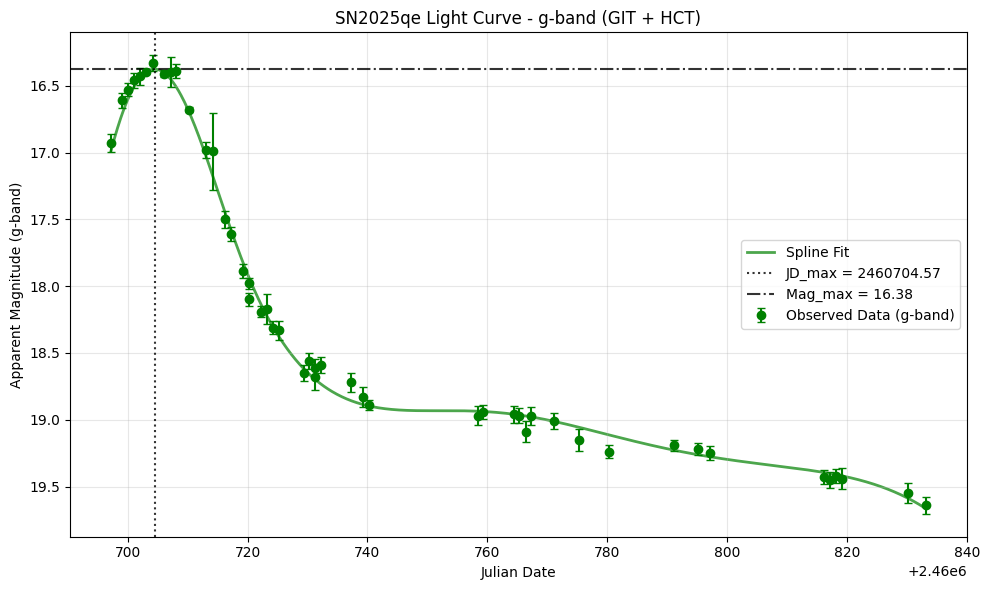

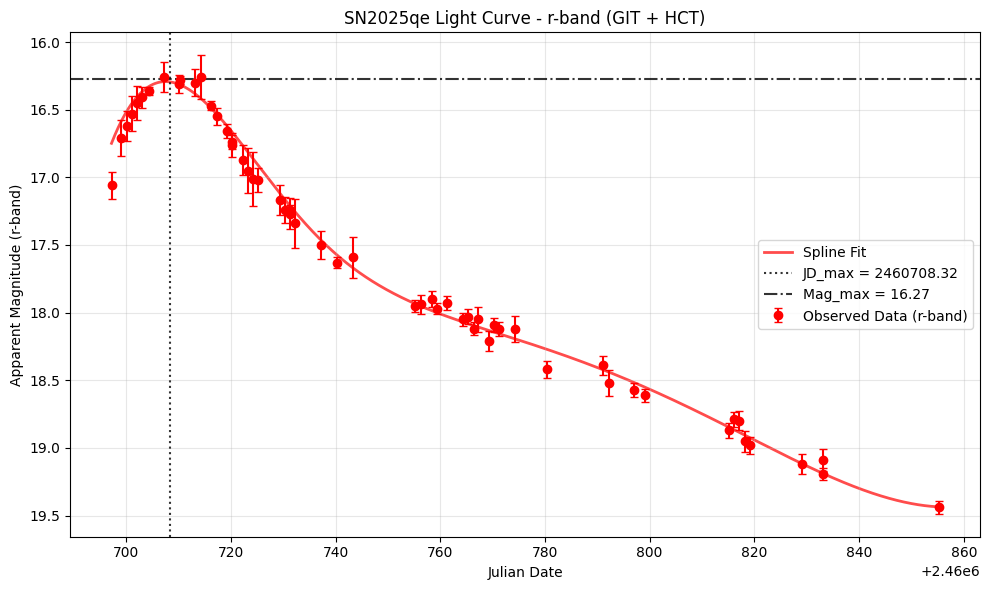

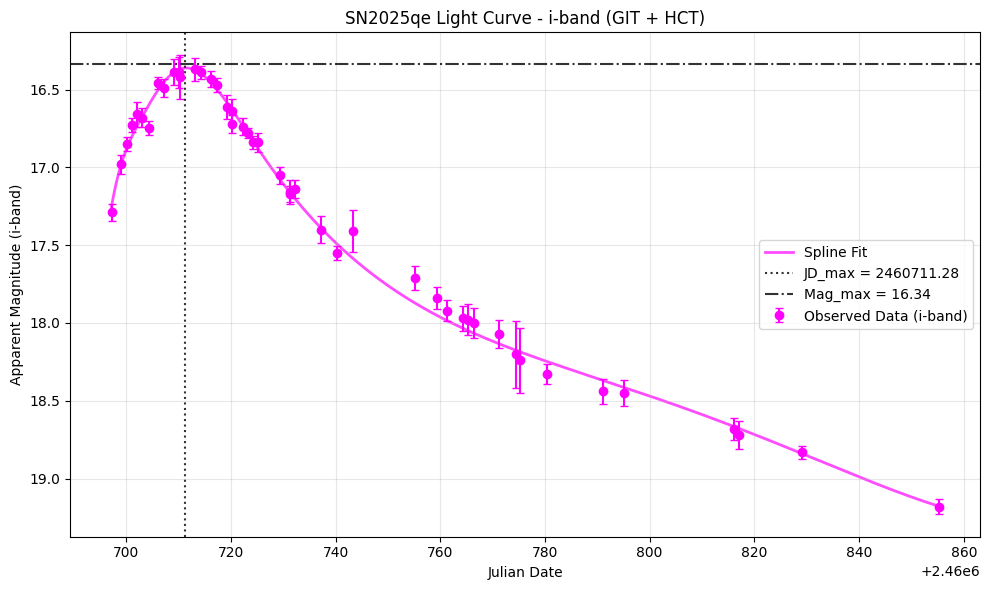

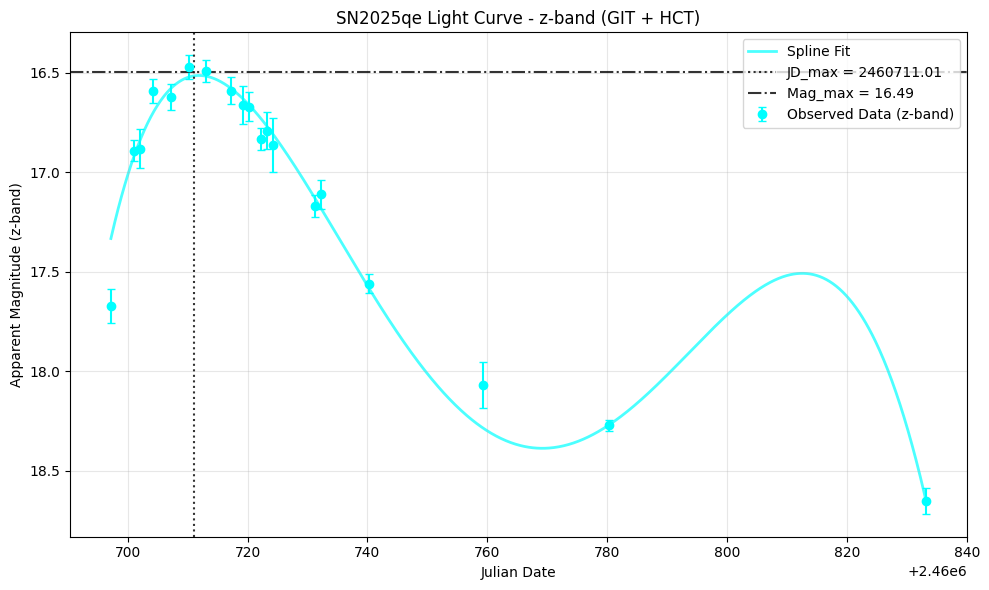

All plots generated.


In [50]:
from scipy.interpolate import UnivariateSpline
import numpy as np

# Initialize an empty dictionary to store optimal smoothing factors
optimal_s_factors = {}

# Iterate through each filter in processed_data
for f, data in processed_data.items():
    jd = data['JD']
    mag = data['mag']
    weights = data['weights']

    # Ensure there are enough data points for spline fitting (k=4 requires at least 5 points)
    if len(jd) < 5:
        print(f"Not enough data points for {f}-band ({len(jd)} points) to perform spline fit. Skipping.")
        continue

    try:
        # Set 's' explicitly to sum(weights), which is the default target for fp when s=None for weighted data.
        # This value should generally be sufficiently large to avoid the "s too small" warning.
        s_value_to_set = np.sum(weights)

        # Create a UnivariateSpline object with k=4 (quartic spline) and the chosen s_value
        # Even if 'fp' attribute is not exposed, setting a robust 's' value like sum(weights)
        # usually allows the spline to be constructed successfully without critical errors.
        spline = UnivariateSpline(jd, mag, w=weights, k=4, s=s_value_to_set)

        # The 'optimal' smoothing factor in this context is the value explicitly set.
        # We acknowledge that 'fp' might not be readily accessible or accurately reflect the 's' target
        # due to numerical issues with the dataset or SciPy's implementation.
        optimal_s = s_value_to_set
        optimal_s_factors[f] = optimal_s
        print(f"Smoothing factor for {f}-band (k=4, s_set={s_value_to_set:.4f}): {optimal_s:.4f}")

    except Exception as e:
        print(f"Could not perform spline fit or determine smoothing factor for {f}-band: {e}")

print("\nSmoothing factors determined for all available filters.")

# Now, the plotting code as originally requested in the subtask:

import matplotlib.pyplot as plt

# Iterate through each filter and generate plots
for f, data in processed_data.items():
    # Check if there is valid data and results for the current filter
    if f not in filters_info or f not in optimal_s_factors or f not in results:
        print(f"Skipping plotting for {f}-band: Missing information.")
        continue

    jd = data['JD']
    mag = data['mag']
    mag_err = data['mag_err']
    weights = data['weights']

    info = filters_info[f]
    optimal_s = optimal_s_factors[f]
    filter_results = results[f]

    # Ensure there are enough data points for spline fitting (k=4 requires at least 5 points)
    if len(jd) < 5:
        print(f"Not enough data points for {f}-band ({len(jd)} points) to perform spline fit. Skipping plot.")
        continue

    plt.figure(figsize=(10, 6))

    # Plot original observed data with error bars
    plt.errorbar(jd, mag, yerr=mag_err, fmt='o', color=info['color'],
                 label=f'Observed Data ({info["label"]})', capsize=3, zorder=2)

    # Fit initial spline using the optimal s and weights
    try:
        spline = UnivariateSpline(jd, mag, w=weights, k=4, s=optimal_s)
        fine_jd = np.linspace(jd.min(), jd.max(), 1000)
        fine_mag = spline(fine_jd)
        plt.plot(fine_jd, fine_mag, '-', color=info['color'], alpha=0.7,
                 label='Spline Fit', linewidth=2, zorder=1)
    except Exception as e:
        print(f"Warning: Could not fit spline for {f}-band during plotting: {e}")

    # Mark the calculated jd_max and mag_max (mean values from results)
    if not np.isnan(filter_results['jd_max']) and not np.isnan(filter_results['mag_max']):
        plt.axvline(filter_results['jd_max'], color='k', linestyle=':',
                    label=f'JD_max = {filter_results["jd_max"]:.2f}', alpha=0.8)
        plt.axhline(filter_results['mag_max'], color='k', linestyle='-.',
                    label=f'Mag_max = {filter_results["mag_max"]:.2f}', alpha=0.8)

    # Invert y-axis for astronomical magnitudes
    plt.gca().invert_yaxis()

    # Add labels, title, and legend, including the smoothing factor
    plt.xlabel('Julian Date')
    plt.ylabel(f'Apparent Magnitude ({info["label"]})')
    plt.title(f'SN2025qe Light Curve - {info["label"]} (GIT + HCT)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("All plots generated.")